In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

#Base path
BASE_PATH = "/kaggle/input/datasets/adityayellamilli/the-kvasircapsule-dataset-images/The Kvasir-Capsule"

TRAIN_CSV = os.path.join(BASE_PATH, "Training_set.csv")
TEST_CSV = os.path.join(BASE_PATH, "Testing_set.csv")

TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR = os.path.join(BASE_PATH, "test")

# Load CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (37790, 2)
Test shape: (9448, 1)


,filename,label
0,Image_1.jpg,Normal clean mucosa
1,Image_2.jpg,Normal clean mucosa
2,Image_3.jpg,Foreign body
3,Image_4.jpg,Normal clean mucosa
4,Image_5.jpg,Normal clean mucosa


In [2]:
def add_full_path(df, image_dir):
    df = df.copy()
    df["filepath"] = df["filename"].apply(lambda x: os.path.join(image_dir,x))
    return df

train_df = add_full_path(train_df, TRAIN_DIR)
test_df = add_full_path(test_df, TEST_DIR)

print(train_df[["filename","filepath"]].head())

      filename                                           filepath
0  Image_1.jpg  /kaggle/input/datasets/adityayellamilli/the-kv...
1  Image_2.jpg  /kaggle/input/datasets/adityayellamilli/the-kv...
2  Image_3.jpg  /kaggle/input/datasets/adityayellamilli/the-kv...
3  Image_4.jpg  /kaggle/input/datasets/adityayellamilli/the-kv...
4  Image_5.jpg  /kaggle/input/datasets/adityayellamilli/the-kv...


In [3]:
print(train_df.columns)
print(test_df.columns)

Index(['filename', 'label', 'filepath'], dtype='object')
Index(['filename', 'filepath'], dtype='object')


## Dataset Exploration

In [4]:
label_col = "label"
class_counts = train_df[label_col].value_counts()

print("Class Distribution:\n")
print(class_counts)

Class Distribution:

label
Normal clean mucosa     27470
Ileocecal valve          3351
Reduced mucosal view     2325
Pylorus                  1223
Angiectasia               693
ulcer                     683
Foreign body              621
Lymphangiectasia          473
Erosion                   405
Blood - fresh             357
Erythema                  127
Polyp                      44
Blood - hematin            10
ampulla_of_vater            8
Name: count, dtype: int64


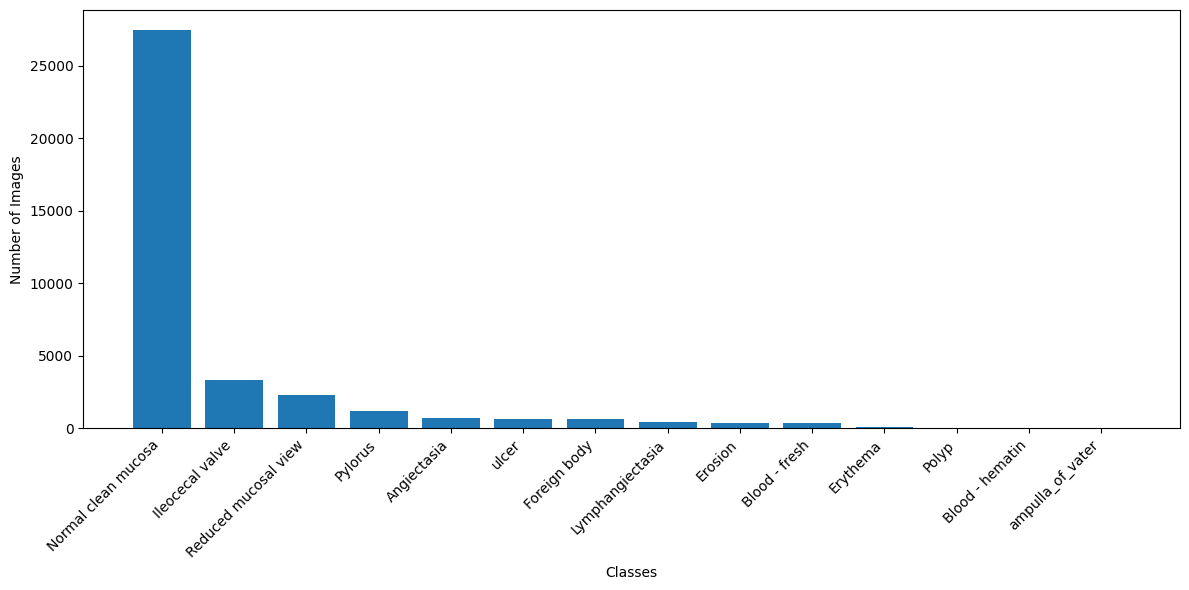

In [5]:
df_counts = class_counts.reset_index()
df_counts.columns = ["Class", "Count"]

plt.figure(figsize=(12,6))
plt.bar(df_counts["Class"], df_counts["Count"])

plt.xticks(rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [6]:
max_class = df_counts.iloc[0]
min_class = df_counts.iloc[-1]

print("Majority Class:", max_class["Class"], "-", max_class["Count"])
print("Minority Class:", min_class["Class"], "-", min_class["Count"])
print(f"Imbalance ratio: {max_class["Count"]/min_class["Count"]:.2f}")

Majority Class: Normal clean mucosa - 27470
Minority Class: ampulla_of_vater - 8
Imbalance ratio: 3433.75


## Train/ Val/ Test Split

In [7]:
from sklearn.model_selection import train_test_split

train_df_split, temp_df = train_test_split(
    train_df,
    test_size=0.30,
    stratify=train_df["label"],
    random_state=42
)

val_df, test_df_split = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [8]:
print("Train size:", len(train_df_split))
print("Validation size:", len(val_df))
print("Test size:", len(test_df_split))

Train size: 26453
Validation size: 5668
Test size: 5669


In [9]:
# Class Distribution
def check_distribution(df, name):
    print(f"\n{name} distribution:\n")
    print(df["label"].value_counts(normalize=True))

check_distribution(train_df_split, "Train")
check_distribution(val_df, "Validation")
check_distribution(test_df_split, "Test")


Train distribution:

label
Normal clean mucosa     0.726912
Ileocecal valve         0.088686
Reduced mucosal view    0.061505
Pylorus                 0.032359
Angiectasia             0.018334
ulcer                   0.018070
Foreign body            0.016444
Lymphangiectasia        0.012513
Erosion                 0.010698
Blood - fresh           0.009451
Erythema                0.003364
Polyp                   0.001172
Blood - hematin         0.000265
ampulla_of_vater        0.000227
Name: proportion, dtype: float64

Validation distribution:

label
Normal clean mucosa     0.726888
Ileocecal valve         0.088567
Reduced mucosal view    0.061574
Pylorus                 0.032287
Angiectasia             0.018349
ulcer                   0.017996
Foreign body            0.016408
Lymphangiectasia        0.012526
Erosion                 0.010762
Blood - fresh           0.009527
Erythema                0.003352
Polyp                   0.001235
Blood - hematin         0.000353
ampulla_of_vate

## Undersampling & Augmention

* Here we are not touching `val_df` and `test_df_split` to prevent data leakage

In [10]:
THRESHOLD = 200

def undersample_dataframe(df, label_col="label", threshold=200):
    balanced_list = []

    for cls in df[label_col].unique():
        class_subset = df[df[label_col] == cls]
        if len(class_subset) > threshold:
            class_subset = class_subset.sample(n=threshold, random_state=42)

        balanced_list.append(class_subset)

    balanced_df = pd.concat(balanced_list).reset_index(drop=True)
    return balanced_df

In [11]:
train_under_df = undersample_dataframe(train_df_split, label_col="label", threshold=THRESHOLD)

print("Original Train Size:", len(train_df_split))
print("After Under-Sampling:", len(train_under_df))

Original Train Size: 26453
After Under-Sampling: 2133


In [12]:
under_counts = train_under_df["label"].value_counts()
print("\nAfter Under-Sampling Distribution:\n")
print(under_counts)


After Under-Sampling Distribution:

label
Normal clean mucosa     200
Angiectasia             200
Reduced mucosal view    200
Erosion                 200
ulcer                   200
Ileocecal valve         200
Blood - fresh           200
Pylorus                 200
Foreign body            200
Lymphangiectasia        200
Erythema                 89
Polyp                    31
Blood - hematin           7
ampulla_of_vater          6
Name: count, dtype: int64


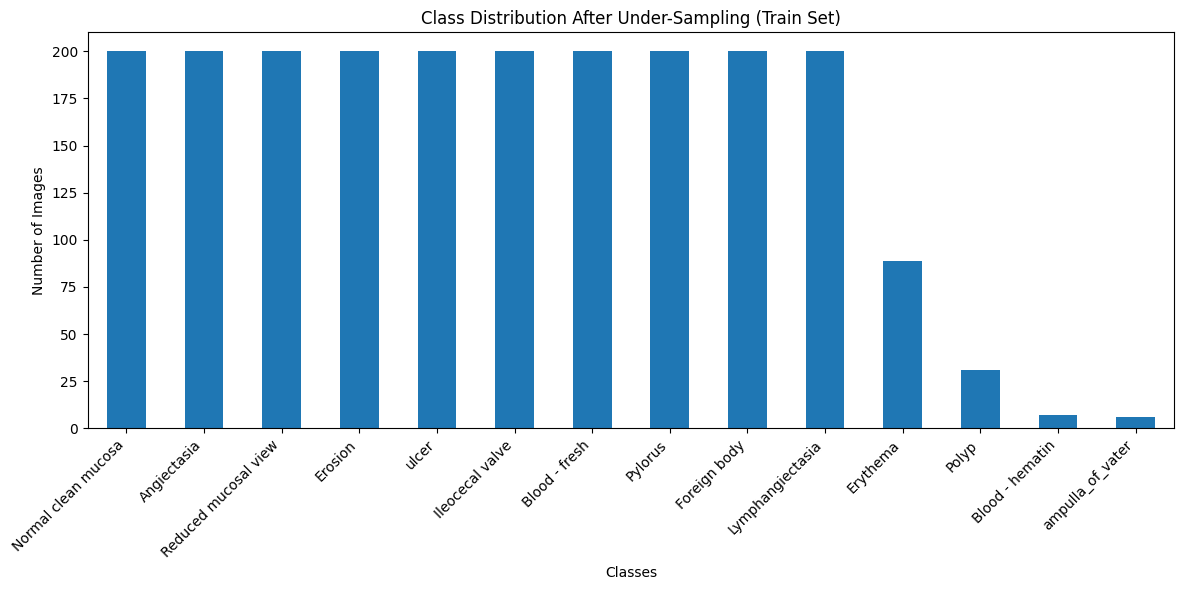

In [13]:
plt.figure(figsize=(12,6))
under_counts.plot(kind='bar')

plt.title("Class Distribution After Under-Sampling (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
data_loss = len(train_df_split) - len(train_under_df)
loss_percent = (data_loss / len(train_df_split)) * 100

print(f"Total Data Loss: {data_loss}")
print(f"Percentage Data Loss: {loss_percent:.2f}%")

Total Data Loss: 24320
Percentage Data Loss: 91.94%


In [15]:
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

AUGMENTED_DIR = "/kaggle/working/augmented_images"
os.makedirs(AUGMENTED_DIR, exist_ok=True)

aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

In [16]:
def augment_minority_classes(df, label_col="label", threshold=200, aug_dir=AUGMENTED_DIR):
    new_rows = []

    for cls in df[label_col].unique():
        class_subset = df[df[label_col] == cls].reset_index(drop=True)
        current_count = len(class_subset)

        if current_count >= threshold:
            # Already at threshold after undersampling — skip
            continue

        needed = threshold - current_count
        print(f"  [{cls}] current={current_count}, need {needed} augmented images")

        generated = 0
        idx = 0

        while generated < needed:
            row = class_subset.iloc[idx % current_count]
            img = Image.open(row["filepath"]).convert("RGB")

            aug_img = aug_transform(img)

            # Save augmented image
            filename = f"aug_{cls.replace(' ', '_')}_{generated}.jpg"
            save_path = os.path.join(aug_dir, filename)
            aug_img.save(save_path)

            new_rows.append({
                "filename": filename,
                "label": cls,
                "filepath": save_path
            })

            generated += 1
            idx += 1

    aug_df = pd.DataFrame(new_rows)
    train_aug_df = pd.concat([df, aug_df], ignore_index=True)
    return train_aug_df

In [17]:
# Run augmentation on train_under_df
print("Augmenting minority classes...\n")
train_aug_df = augment_minority_classes(train_under_df, label_col="label", threshold=THRESHOLD)

print("\nDone!")
print("train_under_df size:", len(train_under_df))
print("train_aug_df size :", len(train_aug_df))

Augmenting minority classes...

  [Erythema] current=89, need 111 augmented images
  [Polyp] current=31, need 169 augmented images
  [ampulla_of_vater] current=6, need 194 augmented images
  [Blood - hematin] current=7, need 193 augmented images

Done!
train_under_df size: 2133
train_aug_df size : 2800



After Augmentation Distribution:

label
Normal clean mucosa     200
Angiectasia             200
Reduced mucosal view    200
Erosion                 200
ulcer                   200
Ileocecal valve         200
Blood - fresh           200
Pylorus                 200
Foreign body            200
Lymphangiectasia        200
Erythema                200
Polyp                   200
ampulla_of_vater        200
Blood - hematin         200
Name: count, dtype: int64


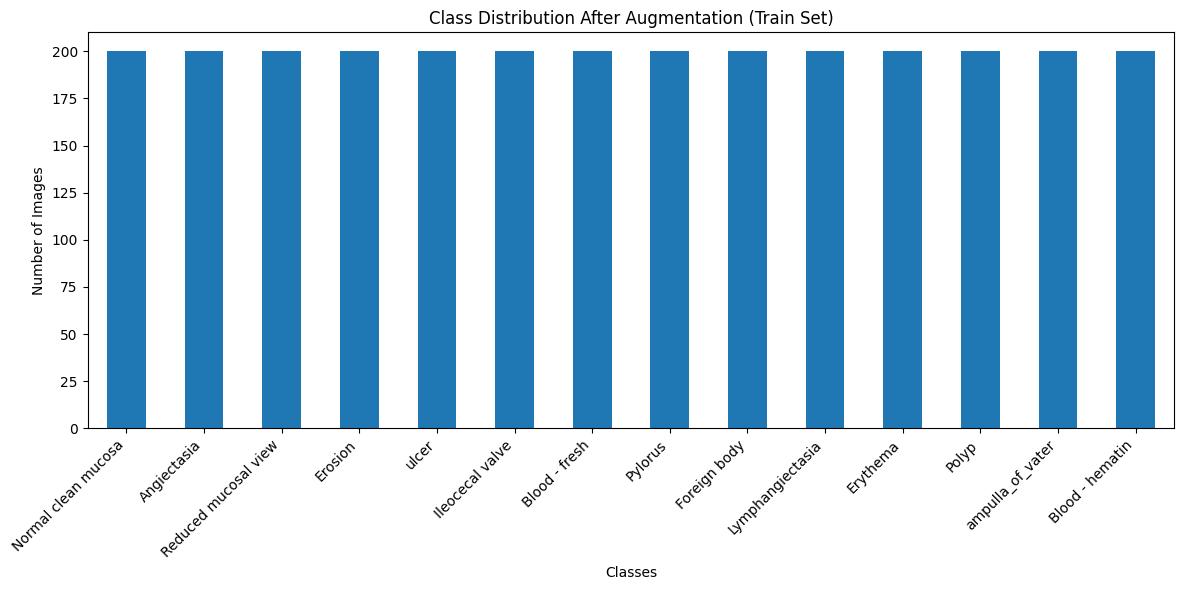

In [18]:
# Updated class distribution after augmentation
aug_counts = train_aug_df["label"].value_counts()
print("\nAfter Augmentation Distribution:\n")
print(aug_counts)

plt.figure(figsize=(12, 6))
aug_counts.plot(kind='bar')
plt.title("Class Distribution After Augmentation (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

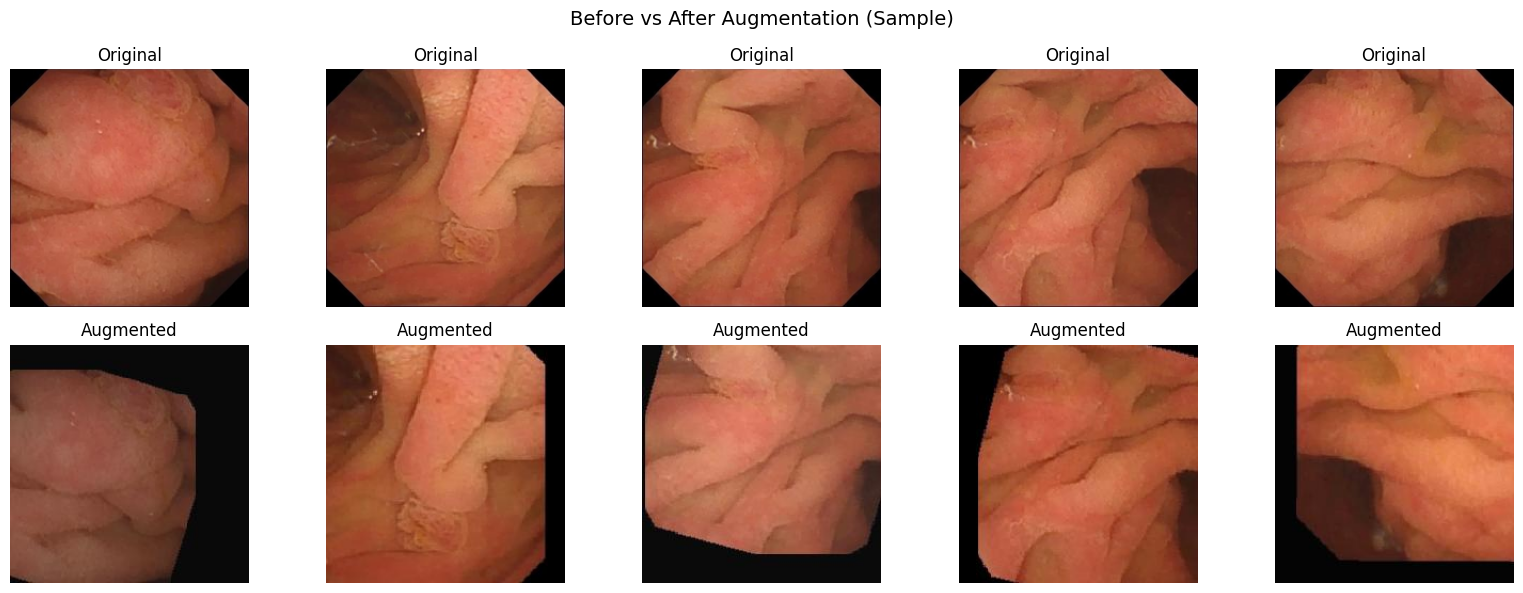

In [ ]:
# Before vs After sample images
import random

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle("Before vs After Augmentation (Sample)", fontsize=14)

# Pick a minority class
sample_class = "ampulla_of_vater"  # smallest class

original_samples = train_under_df[train_under_df["label"] == sample_class]["filepath"].tolist()
augmented_samples = train_aug_df[
    (train_aug_df["label"] == sample_class) &
    (train_aug_df["filepath"].str.startswith(AUGMENTED_DIR))
]["filepath"].tolist()

for i in range(5):
    # Original
    img = Image.open(original_samples[i % len(original_samples)]).convert("RGB").resize((224, 224))
    axes[0][i].imshow(img)
    axes[0][i].set_title("Original")
    axes[0][i].axis("off")

    # Augmented
    img = Image.open(augmented_samples[i]).convert("RGB")
    axes[1][i].imshow(img)
    axes[1][i].set_title("Augmented")
    axes[1][i].axis("off")

plt.tight_layout()
plt.show()

## DataLoader

In [20]:
from torch.utils.data import Dataset, DataLoader

In [21]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [22]:
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [23]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [24]:
label_col = "label"

classes = sorted(train_df_split[label_col].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

num_classes = len(class_to_idx)
print(f"Number of classes: {num_classes}")
print(class_to_idx)

Number of classes: 14
{'Angiectasia': 0, 'Blood - fresh': 1, 'Blood - hematin': 2, 'Erosion': 3, 'Erythema': 4, 'Foreign body': 5, 'Ileocecal valve': 6, 'Lymphangiectasia': 7, 'Normal clean mucosa': 8, 'Polyp': 9, 'Pylorus': 10, 'Reduced mucosal view': 11, 'ampulla_of_vater': 12, 'ulcer': 13}


In [25]:
class WCEDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = self.class_to_idx[row["label"]]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [26]:
BATCH_SIZE = 32

# no imbalance handling 
train_dataset_orig = WCEDataset(train_df_split, class_to_idx, transform=base_transform)
train_loader_orig  = DataLoader(train_dataset_orig, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=2)

# Undersampled only
train_dataset_under = WCEDataset(train_under_df, class_to_idx, transform=base_transform)
train_loader_under  = DataLoader(train_dataset_under, batch_size=BATCH_SIZE,
                                 shuffle=True, num_workers=2)

# Undersampled + Augmented
train_dataset_aug = WCEDataset(train_aug_df, class_to_idx, transform=aug_transform)
train_loader_aug  = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE,
                               shuffle=True, num_workers=2)

# shared across all scenarios
val_dataset  = WCEDataset(val_df,        class_to_idx, transform=val_test_transform)
test_dataset = WCEDataset(test_df_split, class_to_idx, transform=val_test_transform)

val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Original     — train batches:", len(train_loader_orig))
print("Undersampled — train batches:", len(train_loader_under))
print("Augmented    — train batches:", len(train_loader_aug))
print("Val  batches:", len(val_loader))
print("Test batches:", len(test_loader))

Original     — train batches: 827
Undersampled — train batches: 67
Augmented    — train batches: 88
Val  batches: 178
Test batches: 178


## Models

In [27]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [28]:
def build_model(model_name, num_classes):
    if model_name == "efficientnet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "resnet101":
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "mobilenet":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    return model

In [29]:
# Freeze Backbone
def freeze_backbone(model):
    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze only the classifier head
    if hasattr(model, "fc"):          # ResNet101
        for param in model.fc.parameters():
            param.requires_grad = True
    else:                             # EfficientNet, MobileNet
        for param in model.classifier.parameters():
            param.requires_grad = True

In [30]:
# Parameter Summary
def param_summary(model, model_name):
    total      = sum(p.numel() for p in model.parameters())
    trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen     = total - trainable

    print(f"\n{'='*45}")
    print(f"  Model : {model_name}")
    print(f"{'='*45}")
    print(f"  Total      parameters : {total:,}")
    print(f"  Trainable  parameters : {trainable:,}")
    print(f"  Frozen     parameters : {frozen:,}")
    print(f"{'='*45}")

In [31]:
model_efficientnet = build_model("efficientnet", num_classes)
freeze_backbone(model_efficientnet)
model_efficientnet = model_efficientnet.to(device)
param_summary(model_efficientnet, "EfficientNet-B0")

model_resnet101 = build_model("resnet101", num_classes)
freeze_backbone(model_resnet101)
model_resnet101 = model_resnet101.to(device)
param_summary(model_resnet101, "ResNet101")

model_mobilenet = build_model("mobilenet", num_classes)
freeze_backbone(model_mobilenet)
model_mobilenet = model_mobilenet.to(device)
param_summary(model_mobilenet, "MobileNetV2")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 



  Model : EfficientNet-B0
  Total      parameters : 4,025,482
  Trainable  parameters : 17,934
  Frozen     parameters : 4,007,548
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 186MB/s]



  Model : ResNet101
  Total      parameters : 42,528,846
  Trainable  parameters : 28,686
  Frozen     parameters : 42,500,160
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s] 


  Model : MobileNetV2
  Total      parameters : 2,241,806
  Trainable  parameters : 17,934
  Frozen     parameters : 2,223,872


## Intelligent Learning Rate Control

In [32]:
def build_optimizer_and_schedulers(model):
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        weight_decay=1e-4    # L2 regularization
    )

    # ReduceLROnPlateau — reduce LR when val_loss stops improving
    scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
    )

    # CosineAnnealingLR — smooth LR decay over epochs
    scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=10,
        eta_min=1e-6
    )

    return optimizer, scheduler_plateau, scheduler_cosine

In [ ]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / labels.size(0)

def train_model(model, train_loader, val_loader,
                optimizer, scheduler_plateau, scheduler_cosine,
                criterion, device, epochs, tag):
    history = {
        "train_loss": [],
        "val_loss":   [],
        "train_acc":  [],
        "val_acc":    [],
        "lr":         []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f"\nEpoch [{epoch+1}/{epochs}] — {tag}")

        # Train
        model.train()
        train_loss, train_acc = 0.0, 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc  += calculate_accuracy(outputs, labels)

        train_loss /= len(train_loader)
        train_acc  /= len(train_loader)

        # VALIDATION 
        model.eval()
        val_loss, val_acc = 0.0, 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_acc  += calculate_accuracy(outputs, labels)

        val_loss /= len(val_loader)
        val_acc  /= len(val_loader)

        #  SCHEDULERS (step BEFORE logging LR) 
        scheduler_cosine.step()
        scheduler_plateau.step(val_loss)

        #  LOG LR AFTER schedulers have updated it
        current_lr = optimizer.param_groups[0]['lr']

        # SAVE HISTORY
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(f"  LR         : {current_lr:.6f}")
        print(f"  Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
        print(f"  Val   Loss : {val_loss:.4f} | Val   Acc : {val_acc:.4f}")

        # SAVE BEST MODEL
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"/kaggle/working/{tag}_best.pth")
            print(f"  ✓ Best model saved (val_acc={best_val_acc:.4f})")

    return history

In [34]:
def plot_history(history, tag):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Training History — {tag}", fontsize=14)

    # Loss curve
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy curve
    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    # LR curve
    axes[2].plot(epochs, history["lr"], label="Learning Rate", color="green")
    axes[2].set_title("Learning Rate vs Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{tag}_history.png")
    plt.show()

## Training

In [35]:
criterion = nn.CrossEntropyLoss()

scenarios = {
    "original":    train_loader_orig,
    "undersampled": train_loader_under,
    "augmented":   train_loader_aug
}

model_names = ["efficientnet", "resnet101", "mobilenet"]

EPOCHS = 10


  Training EfficientNet-B0 | Scenario: original

Epoch [1/10] — efficientnet_original
  LR         : 0.000976
  Train Loss : 0.7151 | Train Acc : 0.8045
  Val   Loss : 0.4529 | Val   Acc : 0.8734
  ✓ Best model saved (val_acc=0.8734)

Epoch [2/10] — efficientnet_original
  LR         : 0.000905
  Train Loss : 0.5291 | Train Acc : 0.8400
  Val   Loss : 0.3852 | Val   Acc : 0.8899
  ✓ Best model saved (val_acc=0.8899)

Epoch [3/10] — efficientnet_original
  LR         : 0.000794
  Train Loss : 0.4870 | Train Acc : 0.8514
  Val   Loss : 0.3555 | Val   Acc : 0.8959
  ✓ Best model saved (val_acc=0.8959)

Epoch [4/10] — efficientnet_original
  LR         : 0.000655
  Train Loss : 0.4577 | Train Acc : 0.8579
  Val   Loss : 0.3332 | Val   Acc : 0.9033
  ✓ Best model saved (val_acc=0.9033)

Epoch [5/10] — efficientnet_original
  LR         : 0.000501
  Train Loss : 0.4475 | Train Acc : 0.8590
  Val   Loss : 0.3200 | Val   Acc : 0.9075
  ✓ Best model saved (val_acc=0.9075)

Epoch [6/10] — effic

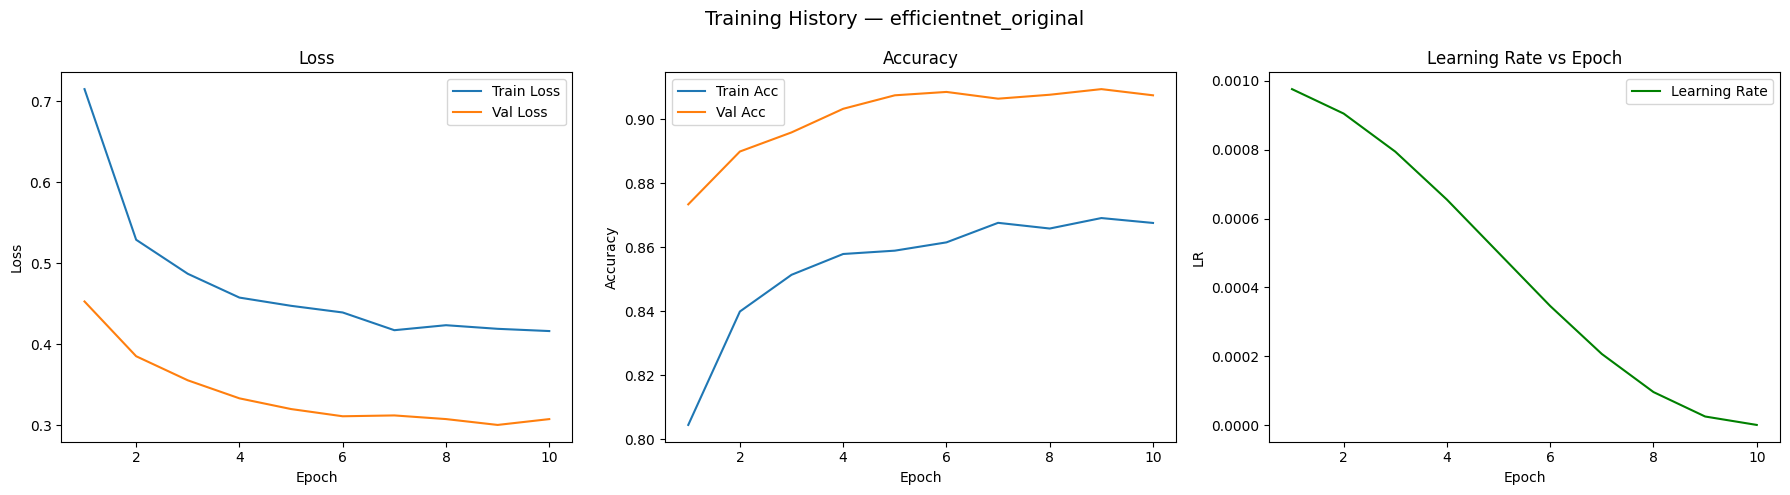


  Training EfficientNet-B0 | Scenario: undersampled

Epoch [1/10] — efficientnet_undersampled
  LR         : 0.000976
  Train Loss : 2.0088 | Train Acc : 0.3989
  Val   Loss : 1.7221 | Val   Acc : 0.5379
  ✓ Best model saved (val_acc=0.5379)

Epoch [2/10] — efficientnet_undersampled
  LR         : 0.000905
  Train Loss : 1.4063 | Train Acc : 0.6214
  Val   Loss : 1.5293 | Val   Acc : 0.5564
  ✓ Best model saved (val_acc=0.5564)

Epoch [3/10] — efficientnet_undersampled
  LR         : 0.000794
  Train Loss : 1.1738 | Train Acc : 0.6802
  Val   Loss : 1.4585 | Val   Acc : 0.5581
  ✓ Best model saved (val_acc=0.5581)

Epoch [4/10] — efficientnet_undersampled
  LR         : 0.000655
  Train Loss : 1.0338 | Train Acc : 0.7019
  Val   Loss : 1.4025 | Val   Acc : 0.5708
  ✓ Best model saved (val_acc=0.5708)

Epoch [5/10] — efficientnet_undersampled
  LR         : 0.000501
  Train Loss : 0.9953 | Train Acc : 0.7166
  Val   Loss : 1.2484 | Val   Acc : 0.6246
  ✓ Best model saved (val_acc=0.624

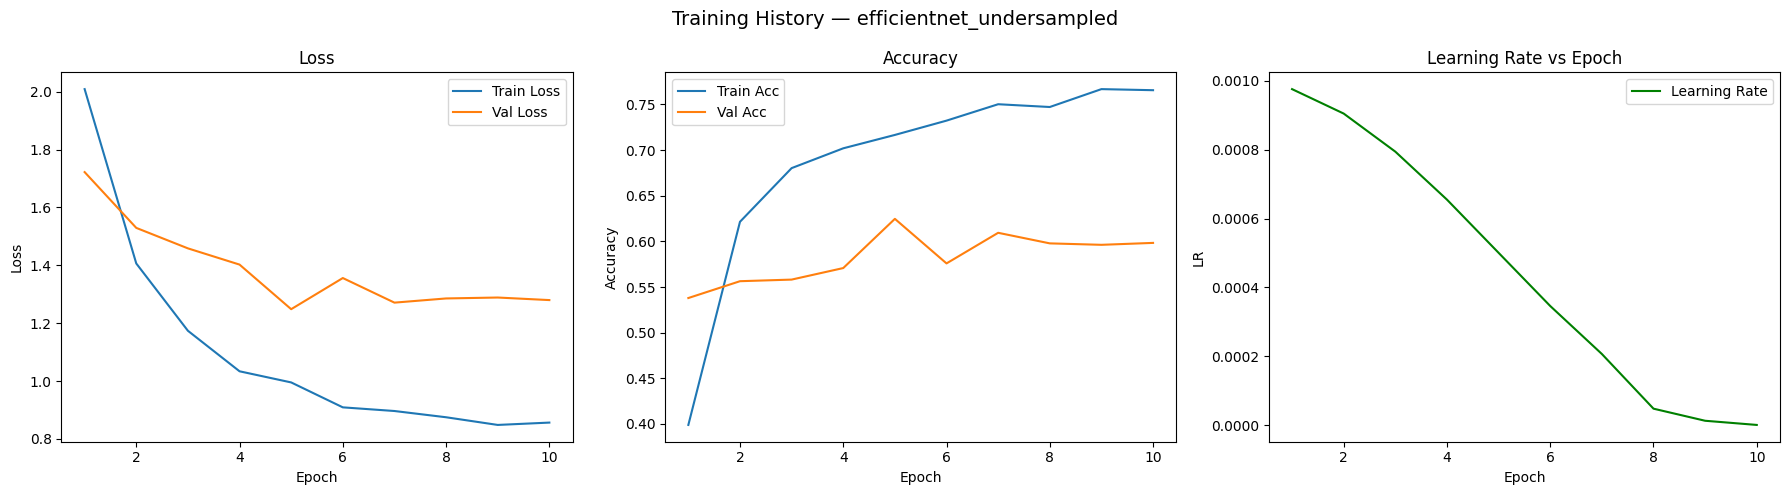


  Training EfficientNet-B0 | Scenario: augmented

Epoch [1/10] — efficientnet_augmented
  LR         : 0.000976
  Train Loss : 2.0379 | Train Acc : 0.4194
  Val   Loss : 2.2957 | Val   Acc : 0.2033
  ✓ Best model saved (val_acc=0.2033)

Epoch [2/10] — efficientnet_augmented
  LR         : 0.000905
  Train Loss : 1.4630 | Train Acc : 0.5938
  Val   Loss : 2.3420 | Val   Acc : 0.1843

Epoch [3/10] — efficientnet_augmented
  LR         : 0.000794
  Train Loss : 1.2681 | Train Acc : 0.6378
  Val   Loss : 2.1056 | Val   Acc : 0.2561
  ✓ Best model saved (val_acc=0.2561)

Epoch [4/10] — efficientnet_augmented
  LR         : 0.000655
  Train Loss : 1.1731 | Train Acc : 0.6495
  Val   Loss : 1.9346 | Val   Acc : 0.3188
  ✓ Best model saved (val_acc=0.3188)

Epoch [5/10] — efficientnet_augmented
  LR         : 0.000501
  Train Loss : 1.1075 | Train Acc : 0.6786
  Val   Loss : 1.9050 | Val   Acc : 0.3350
  ✓ Best model saved (val_acc=0.3350)

Epoch [6/10] — efficientnet_augmented
  LR         :

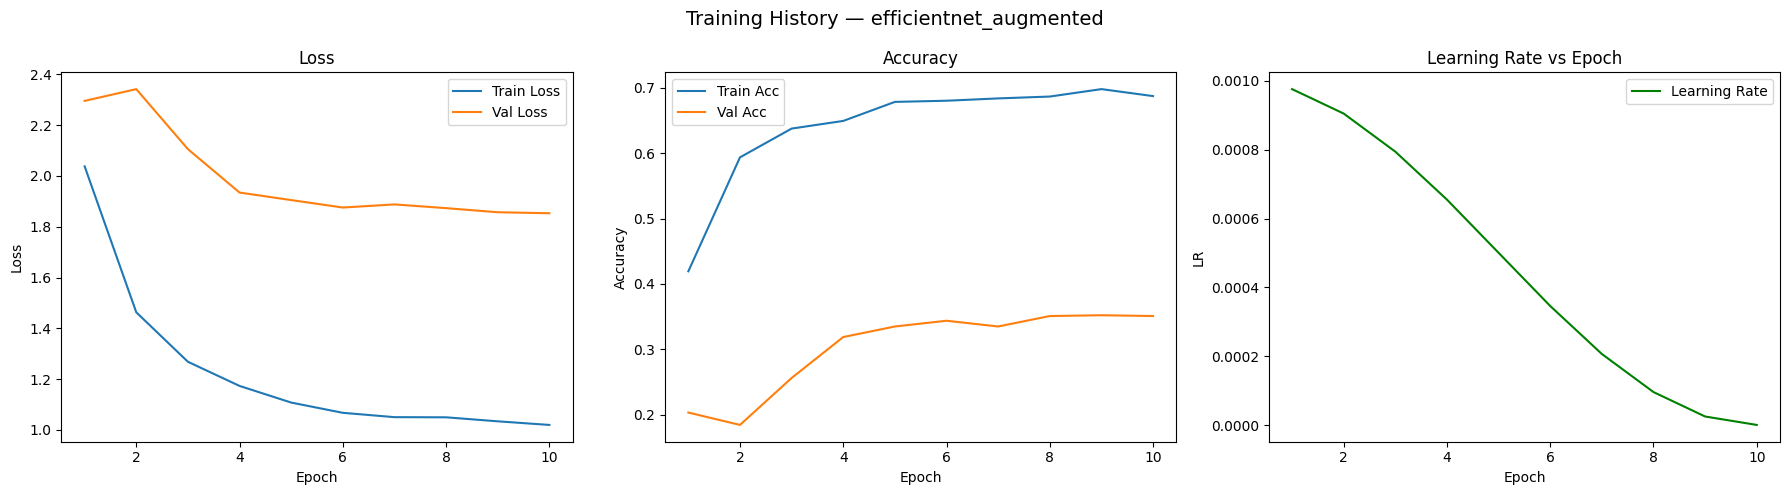

In [36]:
all_histories_efficientnet = {}

for scenario, train_loader in scenarios.items():
    tag = f"efficientnet_{scenario}"
    print(f"\n{'='*55}")
    print(f"  Training EfficientNet-B0 | Scenario: {scenario}")
    print(f"{'='*55}")

    model = build_model("efficientnet", num_classes)
    freeze_backbone(model)
    model = model.to(device)

    optimizer, scheduler_plateau, scheduler_cosine = build_optimizer_and_schedulers(model)

    history = train_model(
        model, train_loader, val_loader,
        optimizer, scheduler_plateau, scheduler_cosine,
        criterion, device, EPOCHS, tag
    )

    all_histories_efficientnet[scenario] = {"model": model, "history": history}
    plot_history(history, tag)


  Training ResNet101 | Scenario: original

Epoch [1/10] — resnet101_original
  LR         : 0.000976
  Train Loss : 0.6744 | Train Acc : 0.8060
  Val   Loss : 0.4448 | Val   Acc : 0.8701
  ✓ Best model saved (val_acc=0.8701)

Epoch [2/10] — resnet101_original
  LR         : 0.000905
  Train Loss : 0.4765 | Train Acc : 0.8537
  Val   Loss : 0.3737 | Val   Acc : 0.8868
  ✓ Best model saved (val_acc=0.8868)

Epoch [3/10] — resnet101_original
  LR         : 0.000794
  Train Loss : 0.4261 | Train Acc : 0.8663
  Val   Loss : 0.3414 | Val   Acc : 0.8933
  ✓ Best model saved (val_acc=0.8933)

Epoch [4/10] — resnet101_original
  LR         : 0.000655
  Train Loss : 0.4007 | Train Acc : 0.8740
  Val   Loss : 0.3253 | Val   Acc : 0.9003
  ✓ Best model saved (val_acc=0.9003)

Epoch [5/10] — resnet101_original
  LR         : 0.000501
  Train Loss : 0.3934 | Train Acc : 0.8743
  Val   Loss : 0.3070 | Val   Acc : 0.9027
  ✓ Best model saved (val_acc=0.9027)

Epoch [6/10] — resnet101_original
  LR   

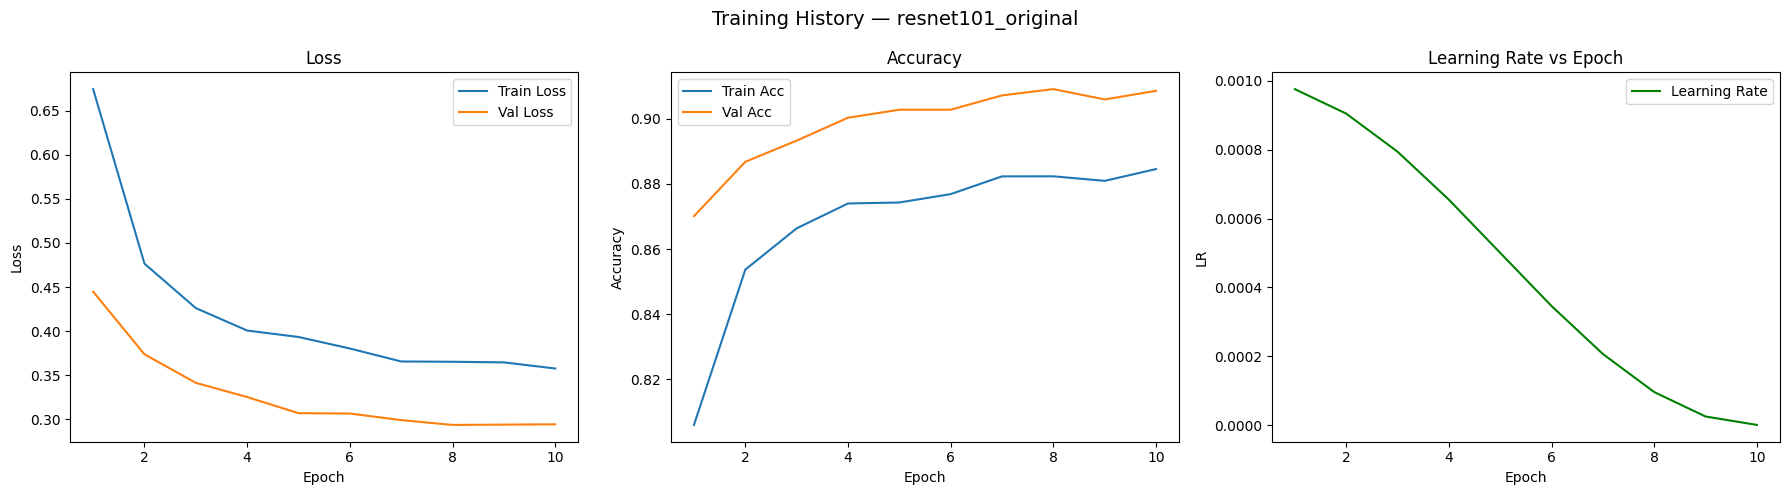


  Training ResNet101 | Scenario: undersampled

Epoch [1/10] — resnet101_undersampled
  LR         : 0.000976
  Train Loss : 1.9999 | Train Acc : 0.3984
  Val   Loss : 1.9379 | Val   Acc : 0.3513
  ✓ Best model saved (val_acc=0.3513)

Epoch [2/10] — resnet101_undersampled
  LR         : 0.000905
  Train Loss : 1.4005 | Train Acc : 0.6172
  Val   Loss : 1.5753 | Val   Acc : 0.5156
  ✓ Best model saved (val_acc=0.5156)

Epoch [3/10] — resnet101_undersampled
  LR         : 0.000794
  Train Loss : 1.1555 | Train Acc : 0.6893
  Val   Loss : 1.3717 | Val   Acc : 0.5925
  ✓ Best model saved (val_acc=0.5925)

Epoch [4/10] — resnet101_undersampled
  LR         : 0.000655
  Train Loss : 1.0224 | Train Acc : 0.7249
  Val   Loss : 1.4032 | Val   Acc : 0.5460

Epoch [5/10] — resnet101_undersampled
  LR         : 0.000501
  Train Loss : 0.9484 | Train Acc : 0.7472
  Val   Loss : 1.3074 | Val   Acc : 0.5915

Epoch [6/10] — resnet101_undersampled
  LR         : 0.000346
  Train Loss : 0.8734 | Train A

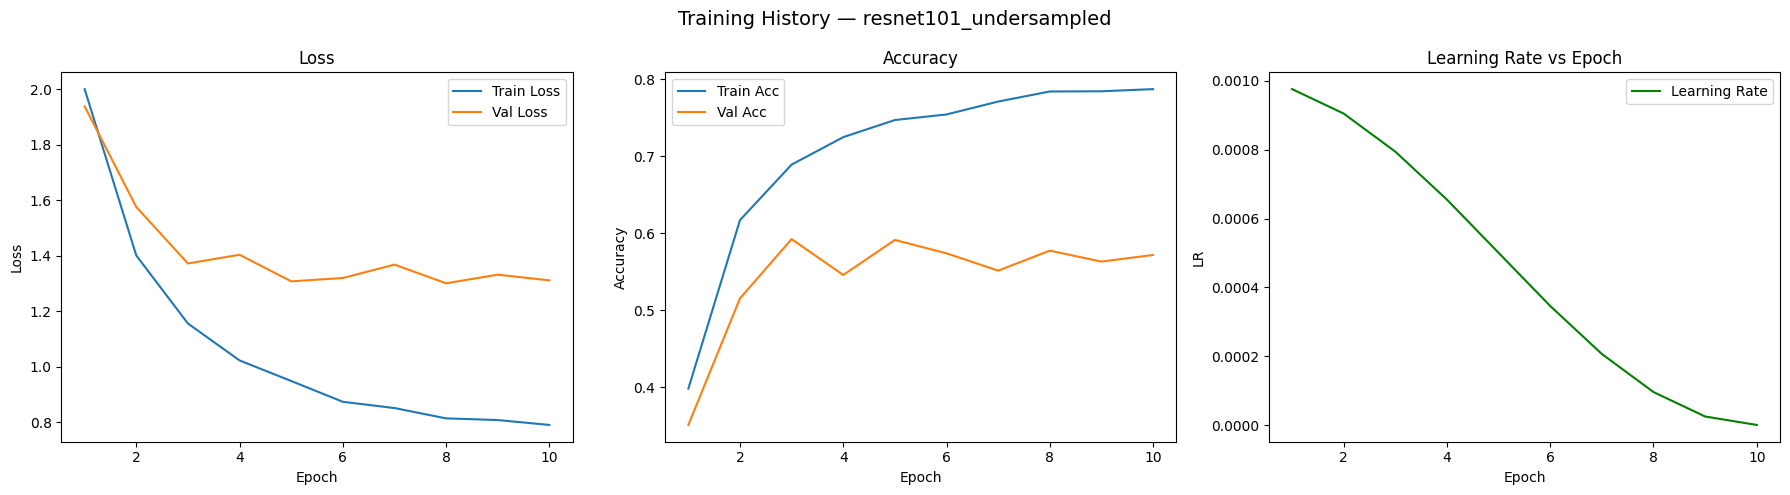


  Training ResNet101 | Scenario: augmented

Epoch [1/10] — resnet101_augmented
  LR         : 0.000976
  Train Loss : 2.1114 | Train Acc : 0.4006
  Val   Loss : 2.1579 | Val   Acc : 0.2526
  ✓ Best model saved (val_acc=0.2526)

Epoch [2/10] — resnet101_augmented
  LR         : 0.000905
  Train Loss : 1.5581 | Train Acc : 0.5824
  Val   Loss : 2.2149 | Val   Acc : 0.1803

Epoch [3/10] — resnet101_augmented
  LR         : 0.000794
  Train Loss : 1.3384 | Train Acc : 0.6300
  Val   Loss : 2.0330 | Val   Acc : 0.2495

Epoch [4/10] — resnet101_augmented
  LR         : 0.000655
  Train Loss : 1.2375 | Train Acc : 0.6413
  Val   Loss : 1.8244 | Val   Acc : 0.3508
  ✓ Best model saved (val_acc=0.3508)

Epoch [5/10] — resnet101_augmented
  LR         : 0.000501
  Train Loss : 1.1617 | Train Acc : 0.6676
  Val   Loss : 1.8691 | Val   Acc : 0.3125

Epoch [6/10] — resnet101_augmented
  LR         : 0.000346
  Train Loss : 1.1286 | Train Acc : 0.6616
  Val   Loss : 1.7517 | Val   Acc : 0.3899
  ✓ 

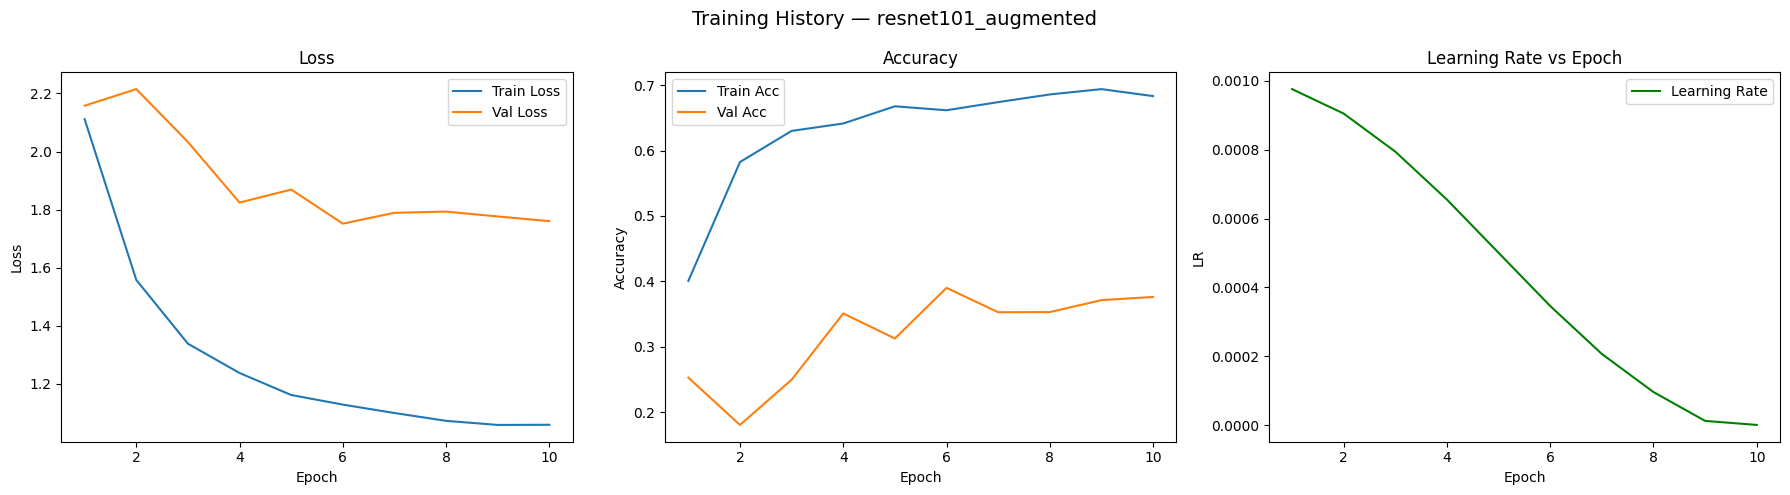

In [ ]:
# Train ResNet101 across 3 scenarios
all_histories_resnet101 = {}

for scenario, train_loader in scenarios.items():
    tag = f"resnet101_{scenario}"
    print(f"\n{'='*55}")
    print(f"  Training ResNet101 | Scenario: {scenario}")
    print(f"{'='*55}")

    model = build_model("resnet101", num_classes)
    freeze_backbone(model)
    model = model.to(device)

    optimizer, scheduler_plateau, scheduler_cosine = build_optimizer_and_schedulers(model)

    history = train_model(
        model, train_loader, val_loader,
        optimizer, scheduler_plateau, scheduler_cosine,
        criterion, device, EPOCHS, tag
    )

    all_histories_resnet101[scenario] = {
        "history": history,
        "model_state": f"/kaggle/working/{tag}_best.pth"
    }

    plot_history(history, tag)


  Training MobileNetV2 | Scenario: original

Epoch [1/10] — mobilenet_original
  LR         : 0.000976
  Train Loss : 0.7202 | Train Acc : 0.7917
  Val   Loss : 0.5069 | Val   Acc : 0.8597
  ✓ Best model saved (val_acc=0.8597)

Epoch [2/10] — mobilenet_original
  LR         : 0.000905
  Train Loss : 0.5370 | Train Acc : 0.8373
  Val   Loss : 0.4331 | Val   Acc : 0.8673
  ✓ Best model saved (val_acc=0.8673)

Epoch [3/10] — mobilenet_original
  LR         : 0.000794
  Train Loss : 0.4958 | Train Acc : 0.8460
  Val   Loss : 0.4007 | Val   Acc : 0.8840
  ✓ Best model saved (val_acc=0.8840)

Epoch [4/10] — mobilenet_original
  LR         : 0.000655
  Train Loss : 0.4701 | Train Acc : 0.8536
  Val   Loss : 0.3867 | Val   Acc : 0.8803

Epoch [5/10] — mobilenet_original
  LR         : 0.000501
  Train Loss : 0.4629 | Train Acc : 0.8537
  Val   Loss : 0.3707 | Val   Acc : 0.8882
  ✓ Best model saved (val_acc=0.8882)

Epoch [6/10] — mobilenet_original
  LR         : 0.000346
  Train Loss : 0.45

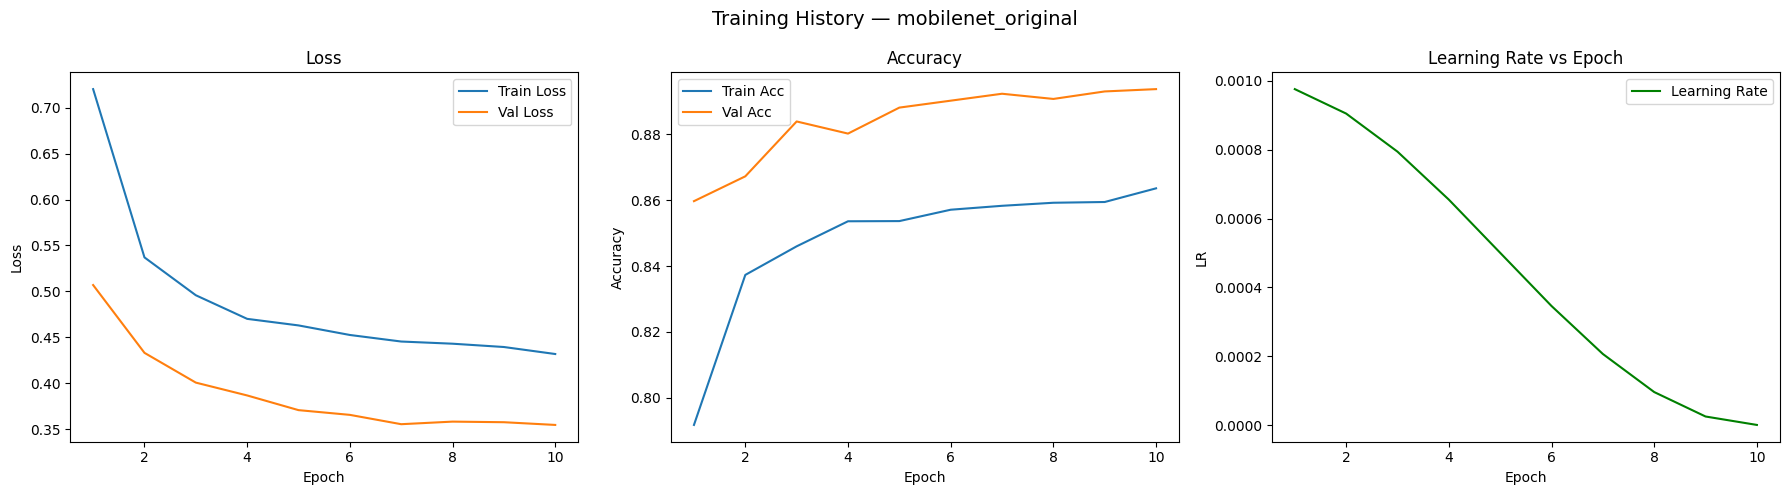


  Training MobileNetV2 | Scenario: undersampled

Epoch [1/10] — mobilenet_undersampled
  LR         : 0.000976
  Train Loss : 2.1028 | Train Acc : 0.3758
  Val   Loss : 1.8999 | Val   Acc : 0.4668
  ✓ Best model saved (val_acc=0.4668)

Epoch [2/10] — mobilenet_undersampled
  LR         : 0.000905
  Train Loss : 1.5721 | Train Acc : 0.5848
  Val   Loss : 1.7136 | Val   Acc : 0.4940
  ✓ Best model saved (val_acc=0.4940)

Epoch [3/10] — mobilenet_undersampled
  LR         : 0.000794
  Train Loss : 1.3409 | Train Acc : 0.6403
  Val   Loss : 1.6434 | Val   Acc : 0.4884

Epoch [4/10] — mobilenet_undersampled
  LR         : 0.000655
  Train Loss : 1.2018 | Train Acc : 0.6809
  Val   Loss : 1.5364 | Val   Acc : 0.5260
  ✓ Best model saved (val_acc=0.5260)

Epoch [5/10] — mobilenet_undersampled
  LR         : 0.000501
  Train Loss : 1.1296 | Train Acc : 0.6802
  Val   Loss : 1.4521 | Val   Acc : 0.5497
  ✓ Best model saved (val_acc=0.5497)

Epoch [6/10] — mobilenet_undersampled
  LR         : 

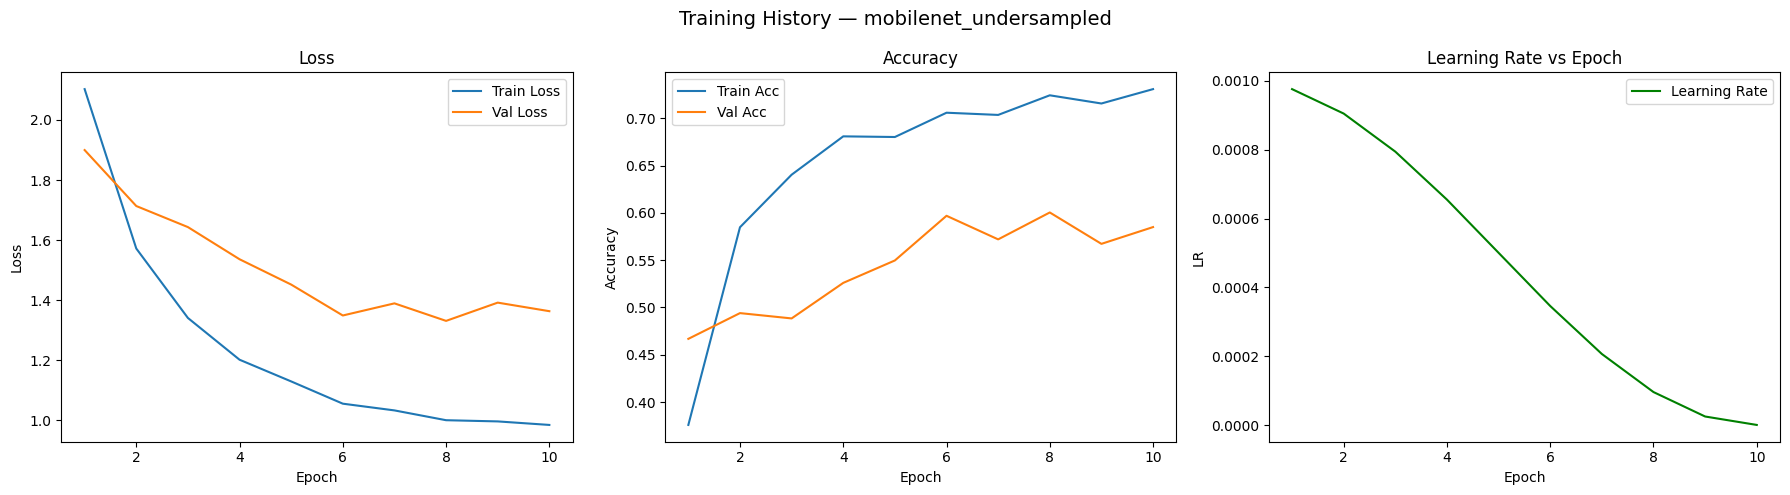


  Training MobileNetV2 | Scenario: augmented

Epoch [1/10] — mobilenet_augmented
  LR         : 0.000976
  Train Loss : 2.1806 | Train Acc : 0.3679
  Val   Loss : 2.2925 | Val   Acc : 0.1548
  ✓ Best model saved (val_acc=0.1548)

Epoch [2/10] — mobilenet_augmented
  LR         : 0.000905
  Train Loss : 1.6573 | Train Acc : 0.5376
  Val   Loss : 1.9983 | Val   Acc : 0.2477
  ✓ Best model saved (val_acc=0.2477)

Epoch [3/10] — mobilenet_augmented
  LR         : 0.000794
  Train Loss : 1.4377 | Train Acc : 0.5831
  Val   Loss : 1.9034 | Val   Acc : 0.2816
  ✓ Best model saved (val_acc=0.2816)

Epoch [4/10] — mobilenet_augmented
  LR         : 0.000655
  Train Loss : 1.3325 | Train Acc : 0.6143
  Val   Loss : 2.0160 | Val   Acc : 0.2259

Epoch [5/10] — mobilenet_augmented
  LR         : 0.000501
  Train Loss : 1.2725 | Train Acc : 0.6200
  Val   Loss : 1.9012 | Val   Acc : 0.2630

Epoch [6/10] — mobilenet_augmented
  LR         : 0.000346
  Train Loss : 1.2365 | Train Acc : 0.6325
  Val  

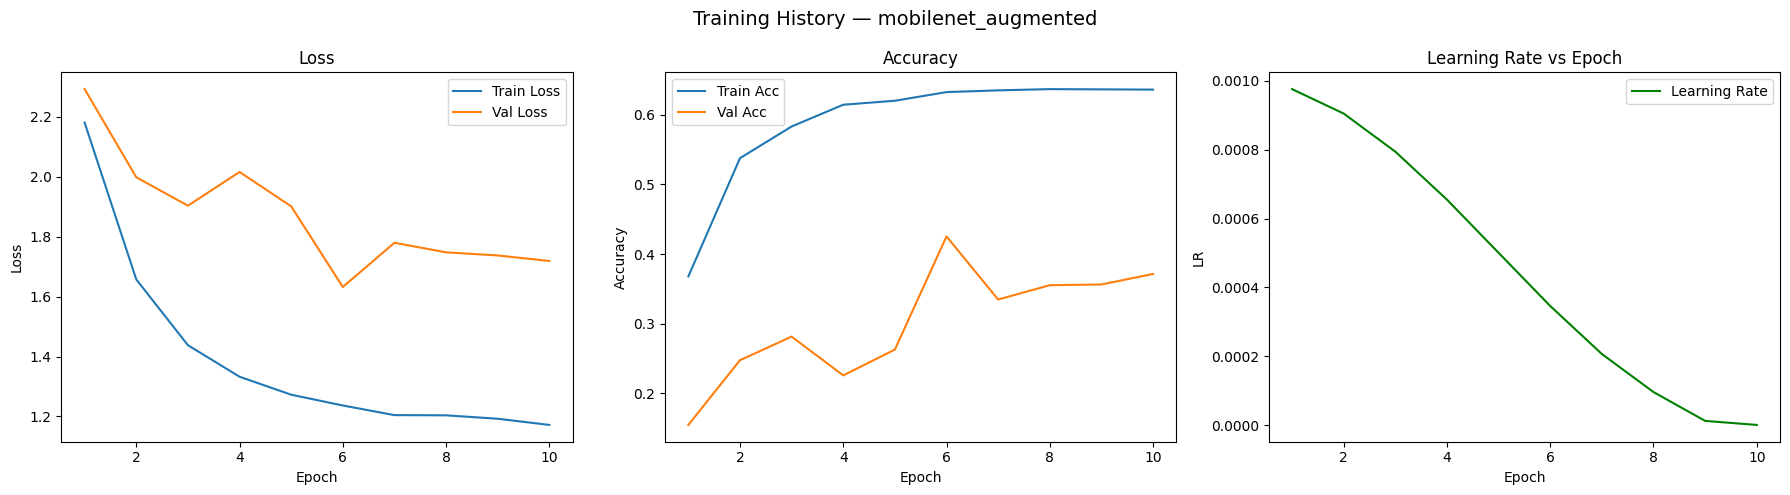

In [ ]:
# Train MobileNetV2 across 3 scenarios
all_histories_mobilenet = {}

for scenario, train_loader in scenarios.items():
    tag = f"mobilenet_{scenario}"
    print(f"\n{'='*55}")
    print(f"  Training MobileNetV2 | Scenario: {scenario}")
    print(f"{'='*55}")

    model = build_model("mobilenet", num_classes)
    freeze_backbone(model)
    model = model.to(device)

    optimizer, scheduler_plateau, scheduler_cosine = build_optimizer_and_schedulers(model)

    history = train_model(
        model, train_loader, val_loader,
        optimizer, scheduler_plateau, scheduler_cosine,
        criterion, device, EPOCHS, tag
    )

    all_histories_mobilenet[scenario] = {
        "history": history,
        "model_state": f"/kaggle/working/{tag}_best.pth"
    }

    plot_history(history, tag)

In [ ]:
# Evaluation Function
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_model(model_name, scenario, model_state_path, test_loader, device):
    model = build_model(model_name, num_classes)
    model.load_state_dict(torch.load(model_state_path, map_location=device))
    model = model.to(device)
    model.eval()

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return acc, prec, rec, f1, all_labels, all_preds

In [ ]:
# Confusion Matrix Plotting
def plot_confusion_matrix(all_labels, all_preds, tag):
    cm = confusion_matrix(all_labels, all_preds)
    class_names = [idx_to_class[i] for i in range(num_classes)]

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names,
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix — {tag}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{tag}_confusion_matrix.png")
    plt.show()


Evaluating: efficientnet_original


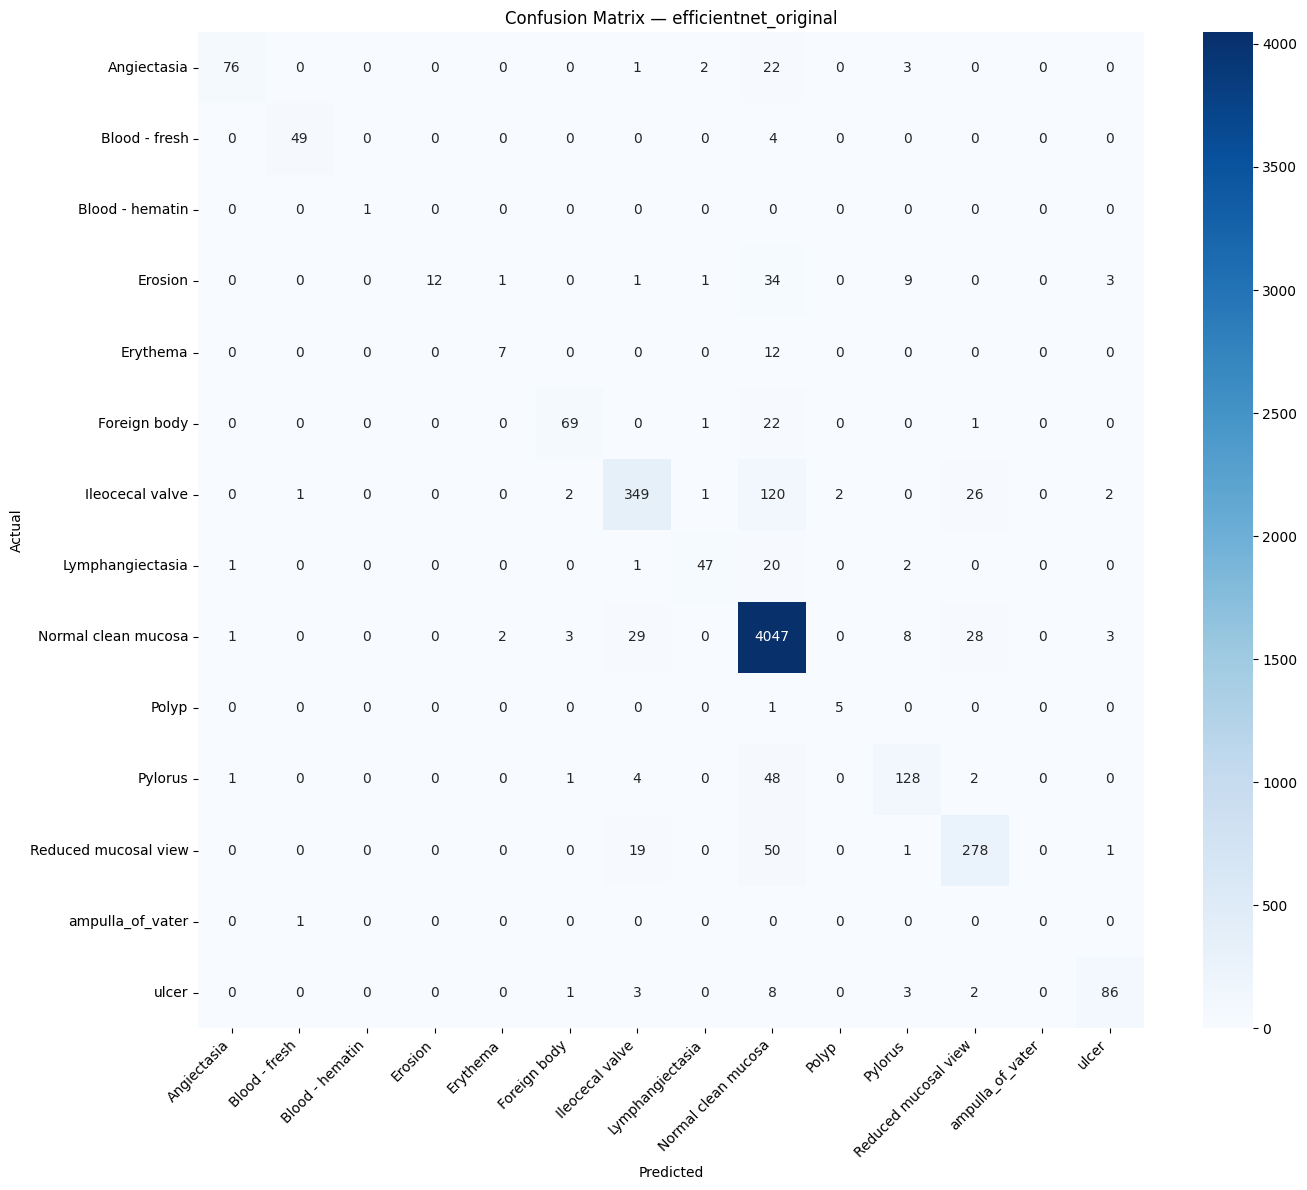


Evaluating: efficientnet_undersampled


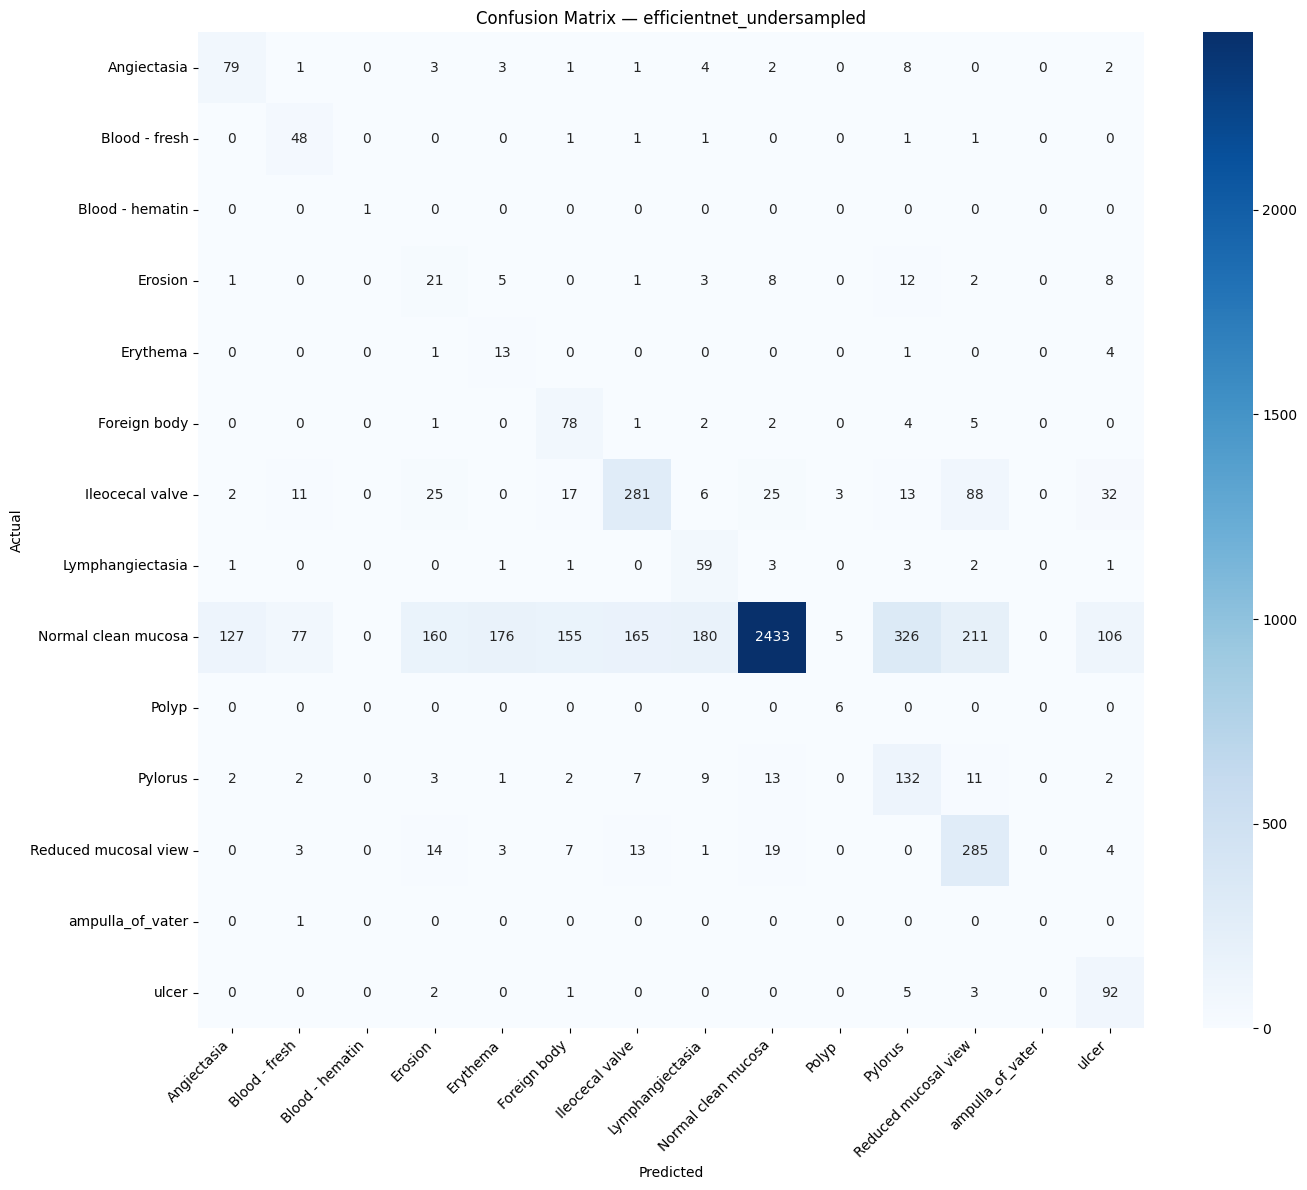


Evaluating: efficientnet_augmented


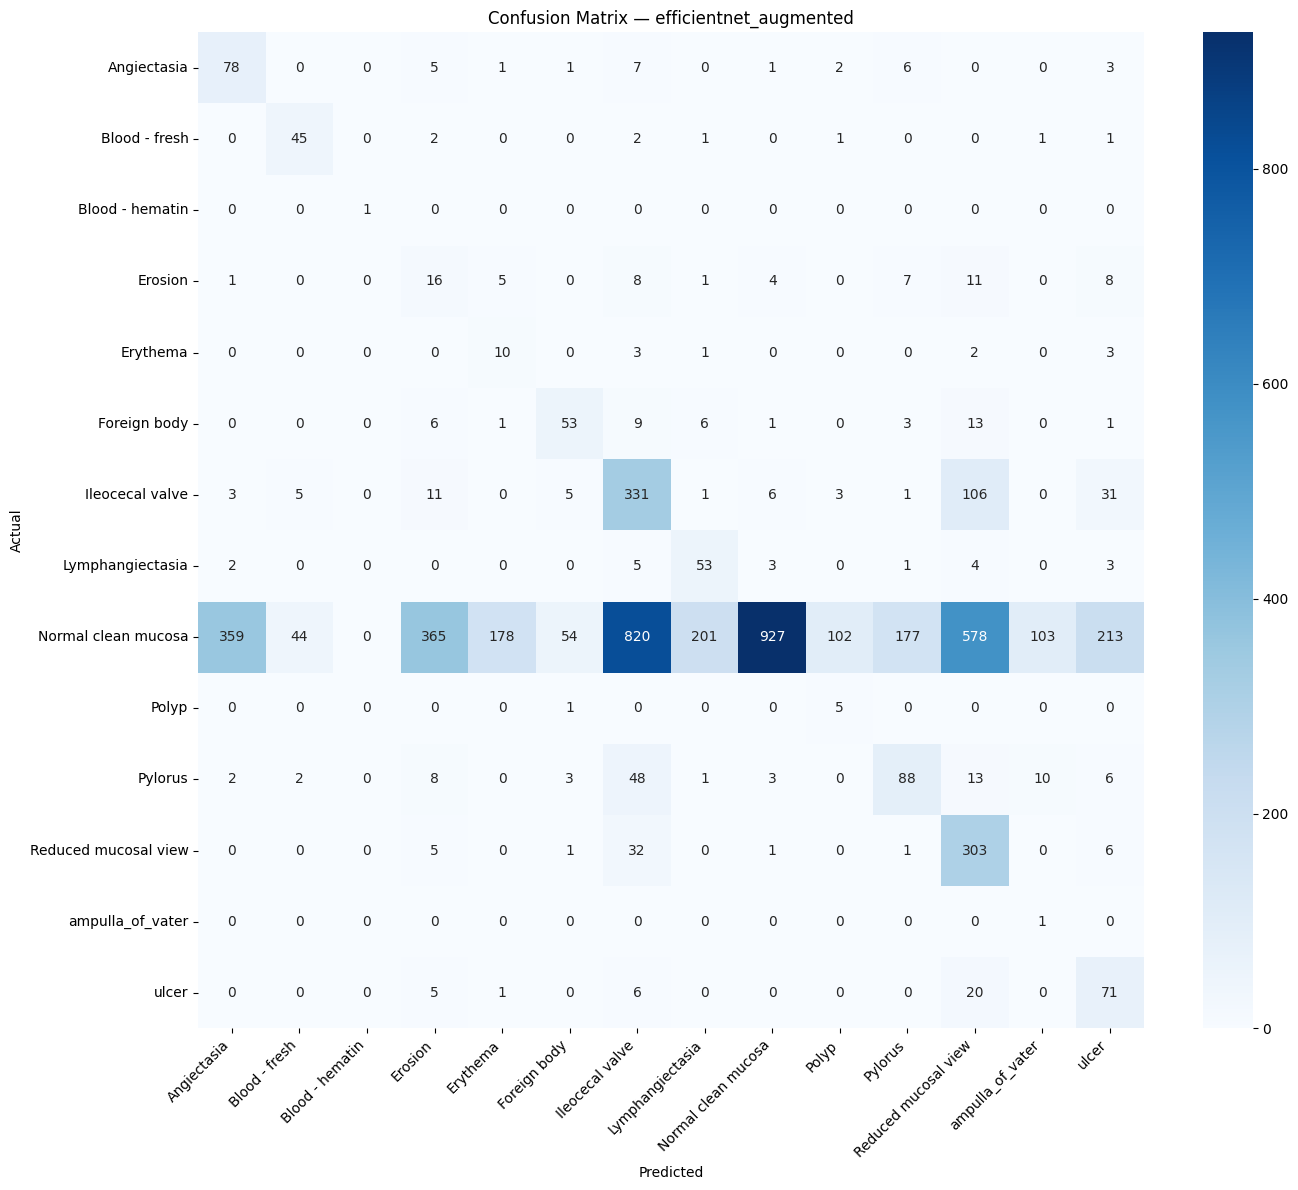


Evaluating: resnet101_original


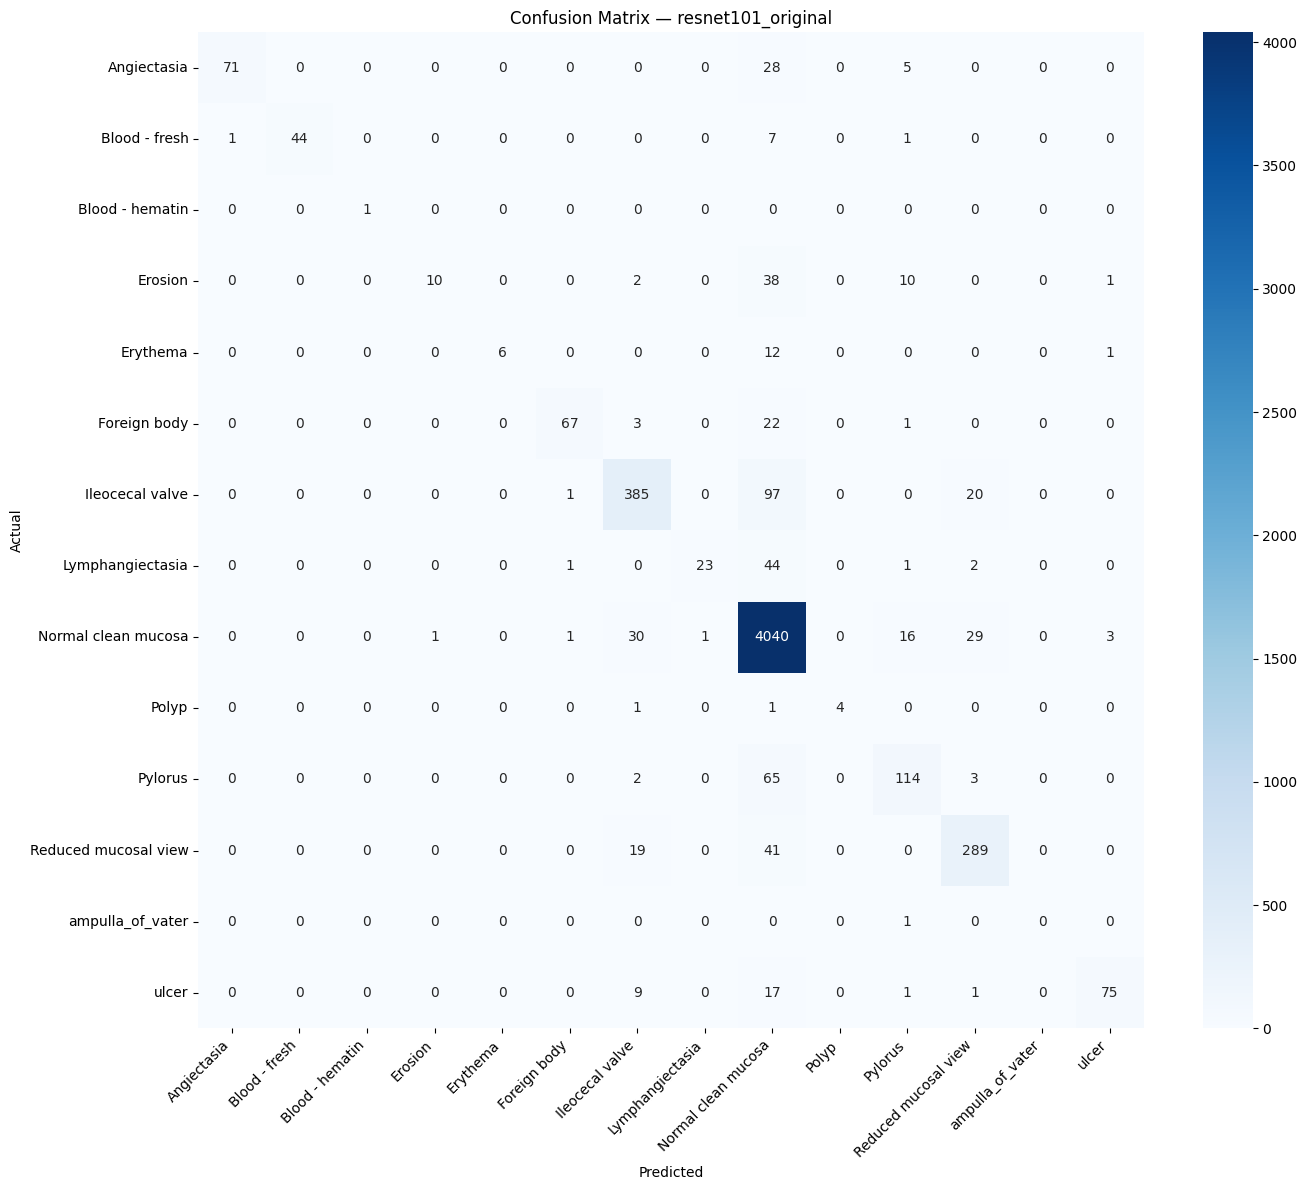


Evaluating: resnet101_undersampled


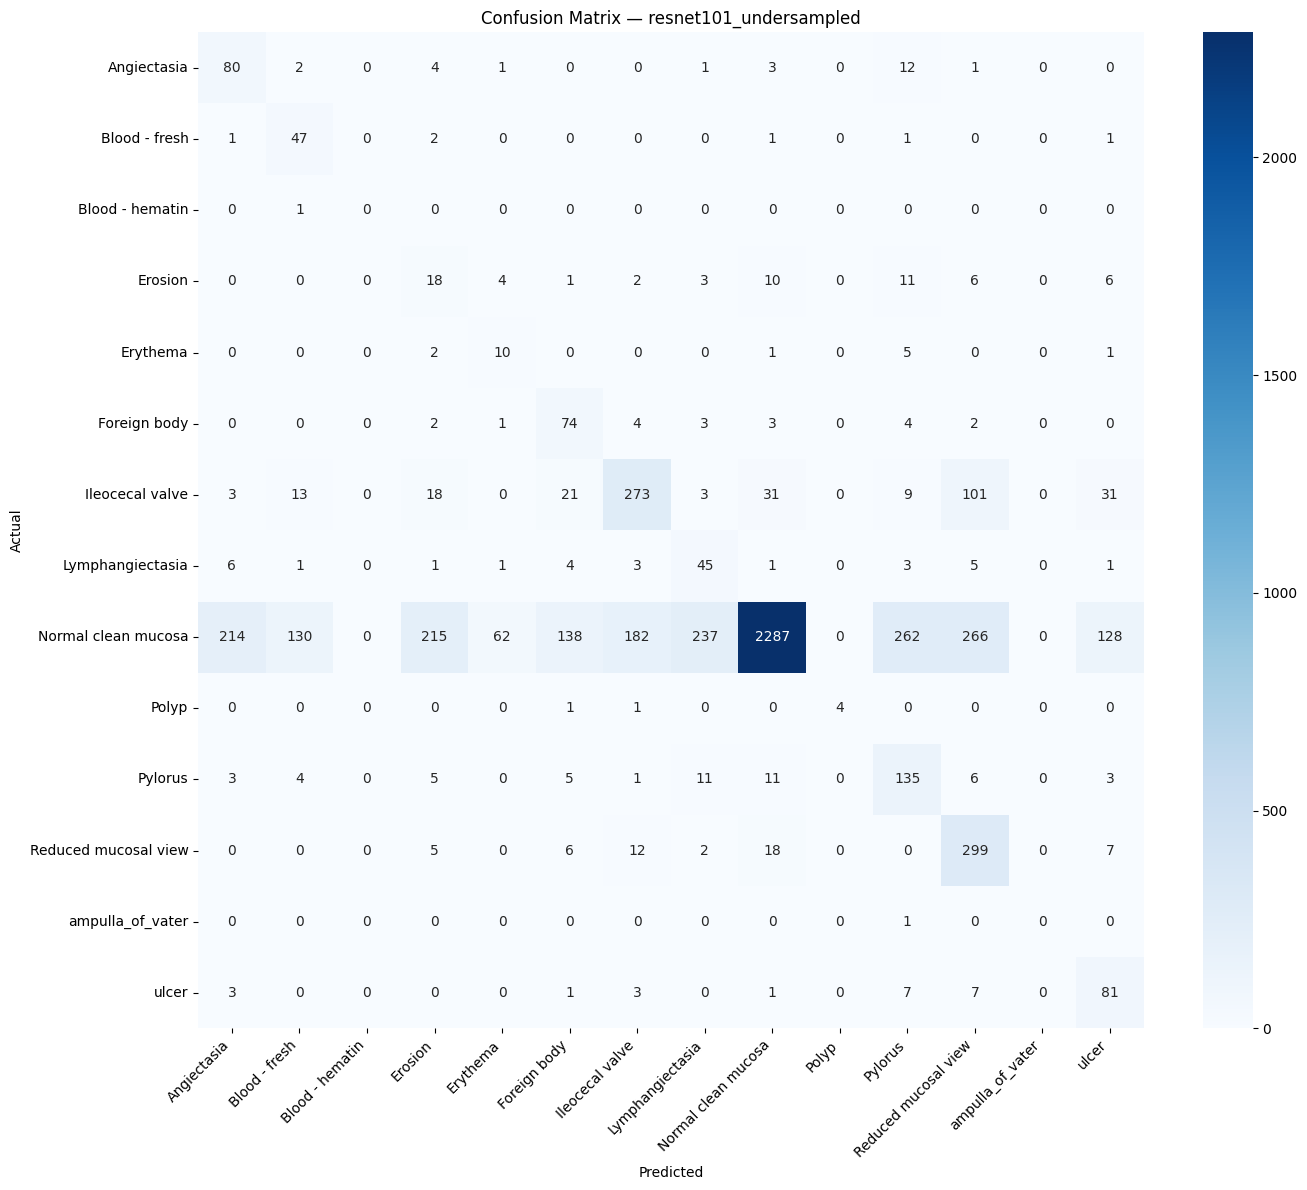


Evaluating: resnet101_augmented


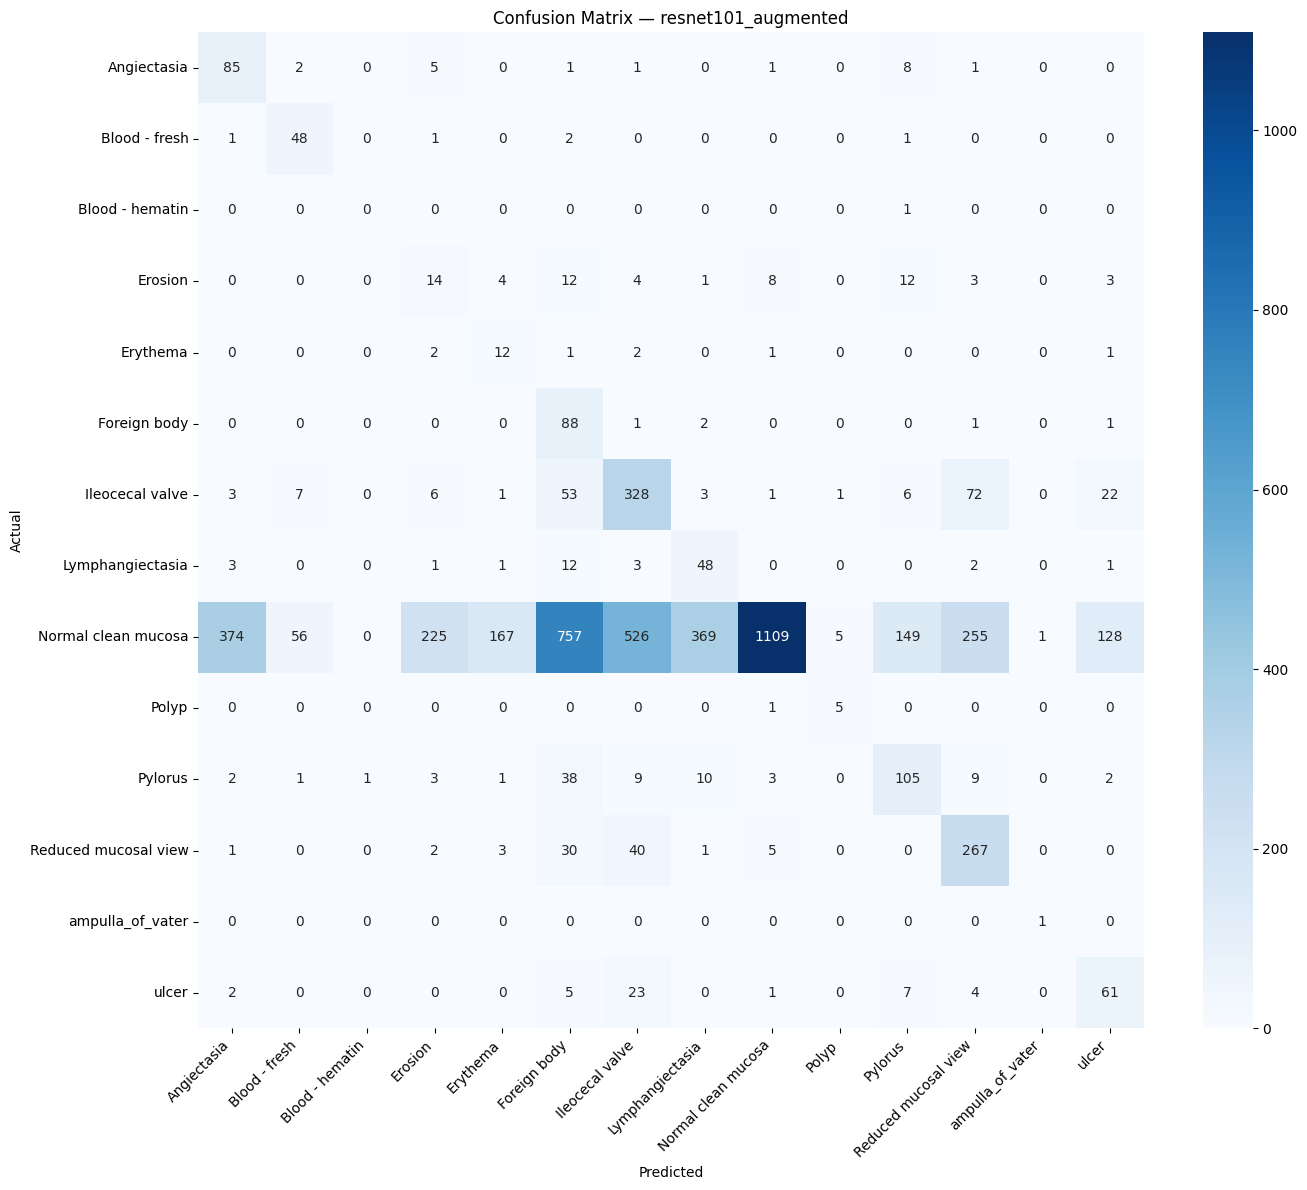


Evaluating: mobilenet_original


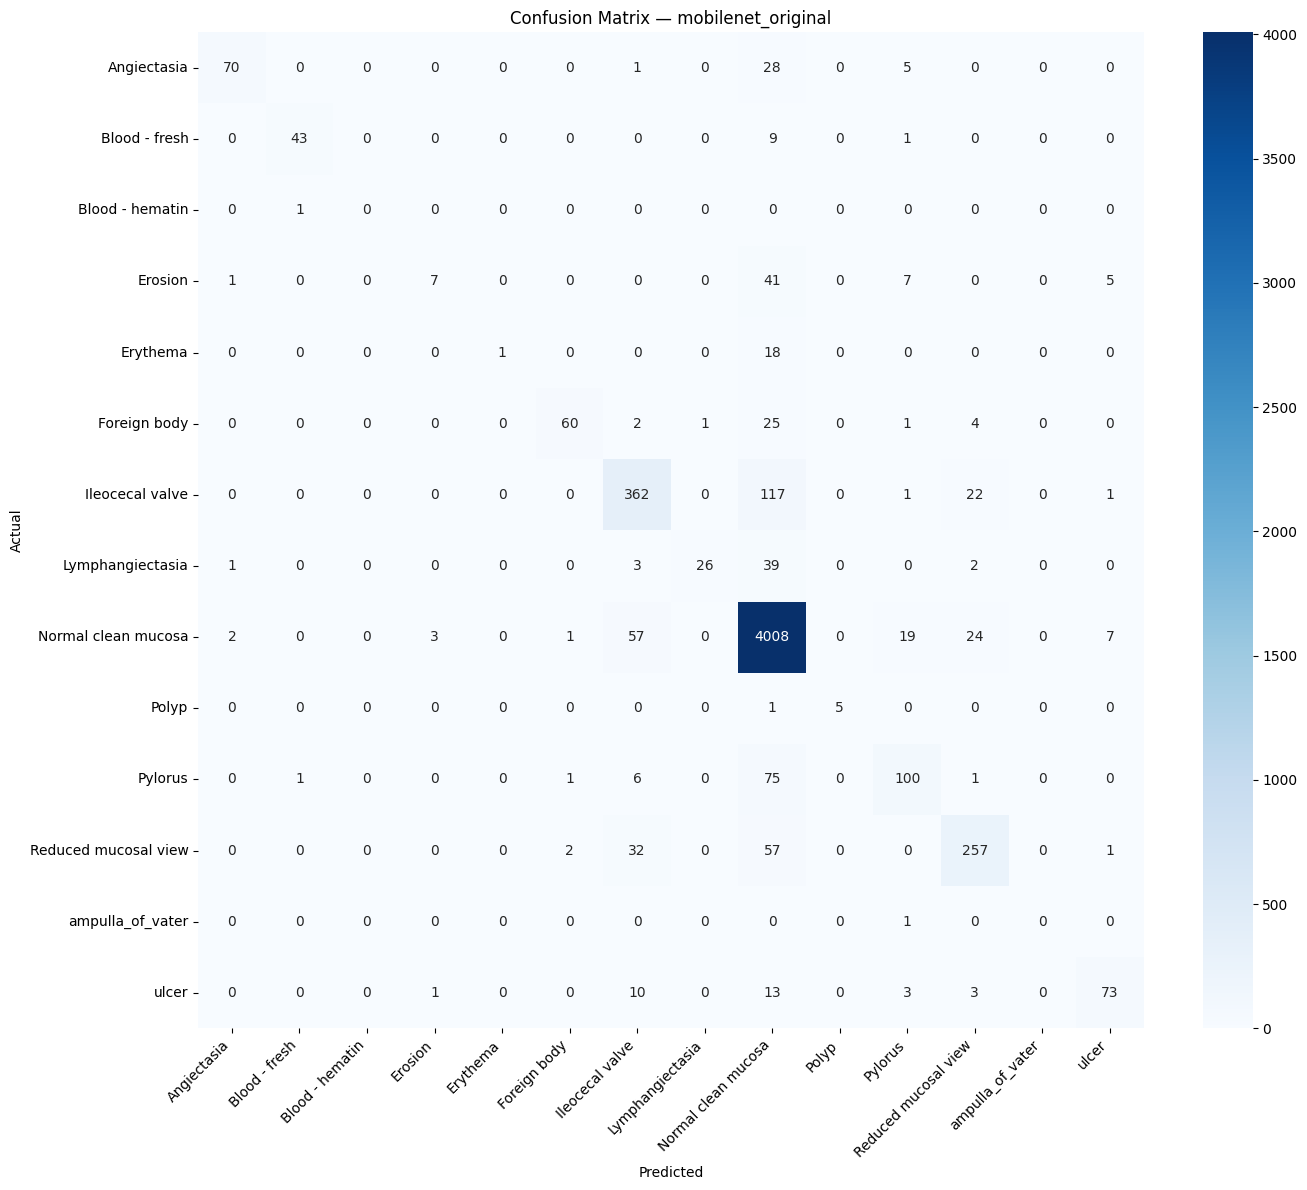


Evaluating: mobilenet_undersampled


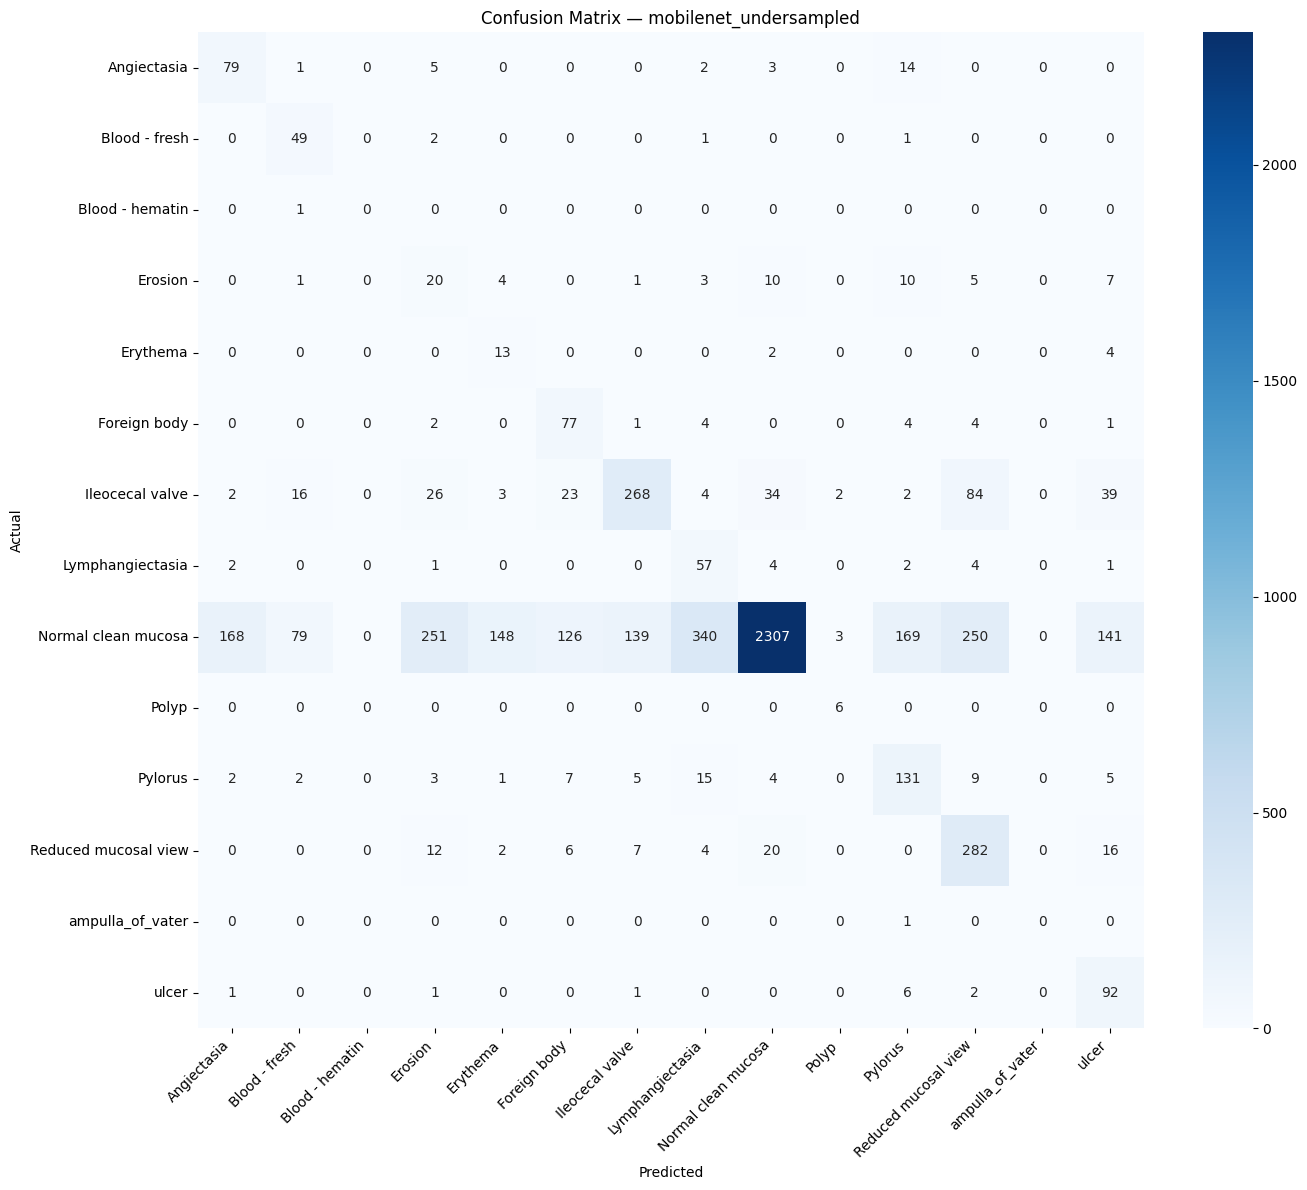


Evaluating: mobilenet_augmented


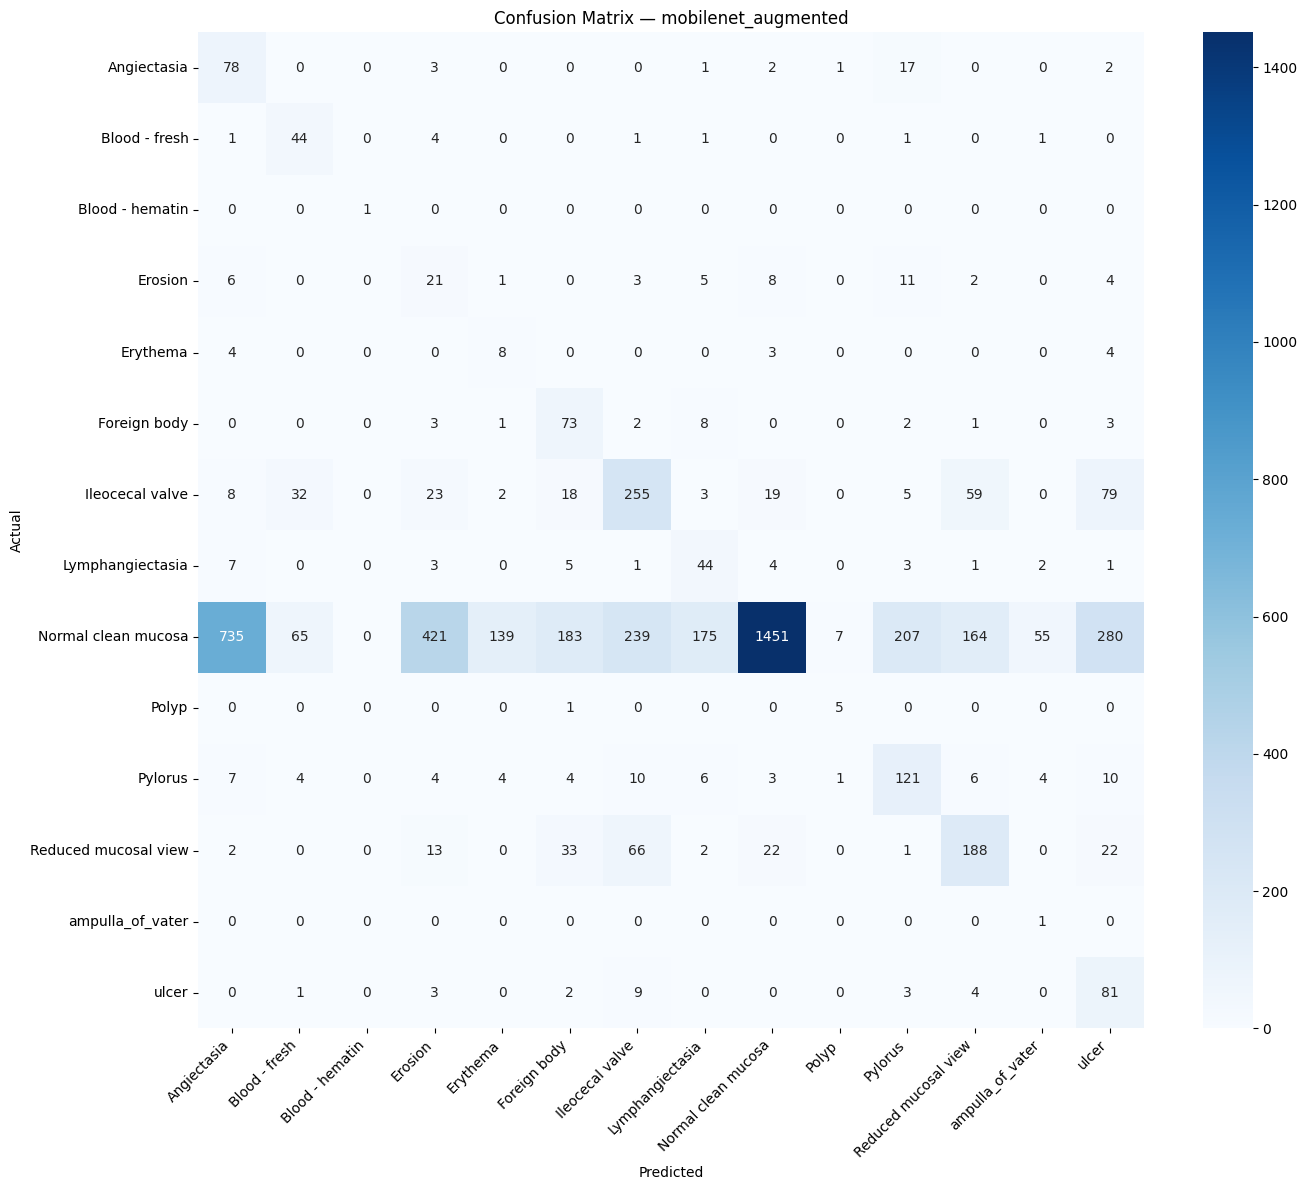

In [ ]:
# Run Evaluation for All Models All Scenarios
results = []

eval_map = {
    "efficientnet": all_histories_efficientnet,
    "resnet101":    all_histories_resnet101,
    "mobilenet":    all_histories_mobilenet
}

for model_name, histories in eval_map.items():
    for scenario, info in histories.items():
        tag = f"{model_name}_{scenario}"
        model_state_path = f"/kaggle/working/{tag}_best.pth"

        print(f"\nEvaluating: {tag}")

        acc, prec, rec, f1, all_labels, all_preds = evaluate_model(
            model_name, scenario, model_state_path, test_loader, device
        )

        results.append({
            "Model":     model_name,
            "Scenario":  scenario,
            "Accuracy":  round(acc,  4),
            "Precision": round(prec, 4),
            "Recall":    round(rec,  4),
            "F1-Score":  round(f1,   4)
        })

        plot_confusion_matrix(all_labels, all_preds, tag)

In [ ]:
# Comparison Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["Model", "Scenario"]).reset_index(drop=True)

print("\n===== Task 7 — Model Comparison Table =====\n")
print(results_df.to_string(index=False))

results_df.to_csv("/kaggle/working/task7_comparison.csv", index=False)
print("\nSaved to /kaggle/working/task7_comparison.csv")


===== Task 7 — Model Comparison Table =====

       Model     Scenario  Accuracy  Precision  Recall  F1-Score
efficientnet    augmented    0.3496     0.7853  0.3496    0.3681
efficientnet     original    0.9092     0.9076  0.9092    0.9030
efficientnet undersampled    0.6223     0.8225  0.6223    0.6717
   mobilenet    augmented    0.4182     0.7888  0.4182    0.4834
   mobilenet     original    0.8841     0.8797  0.8841    0.8743
   mobilenet undersampled    0.5964     0.8221  0.5964    0.6520
   resnet101    augmented    0.3830     0.7996  0.3830    0.4208
   resnet101     original    0.9047     0.9043  0.9047    0.8968
   resnet101 undersampled    0.5915     0.8105  0.5915    0.6423

Saved to /kaggle/working/task7_comparison.csv
